# 2. Data understanding part

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import copy
from scipy import stats
from collections import Counter
from sklearn.model_selection import train_test_split
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load CSV file into a DataFrame
stdData = pd.read_csv("data.csv",sep=';')
stdData

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [3]:
stdData.shape

(4424, 37)

In [4]:
stdData.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
stdData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
stdData = stdData.rename(columns={'Nacionality': 'Nationality'})
stdData = stdData.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'})

In [7]:
stdData.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [8]:
orgData = copy.deepcopy(stdData)

In [9]:
stdData['Target'].value_counts()

Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

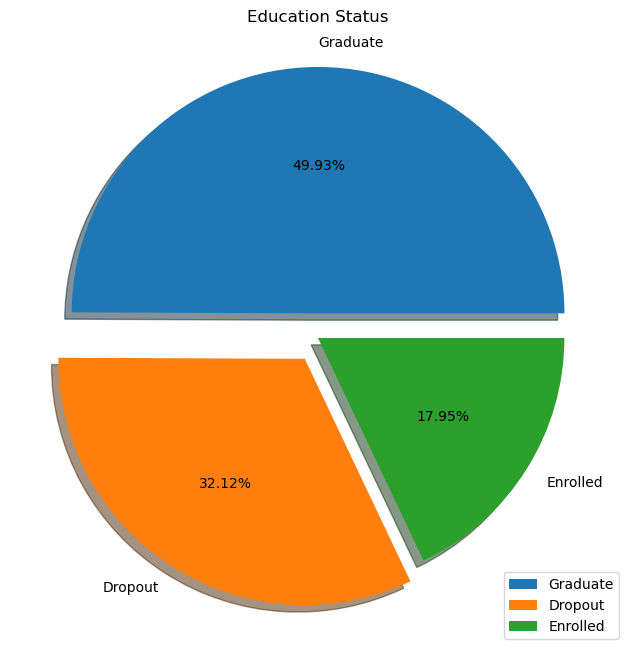

In [10]:
plt.figure(figsize=(8,8))
plt.title("Education Status")
plt.pie(stdData['Target'].value_counts(),labels = ['Graduate','Dropout','Enrolled'],
       explode = (0.1,0.1,0.0), autopct='%1.2f%%', shadow = True)
plt.legend(loc='lower right')

<function matplotlib.pyplot.show(close=None, block=None)>

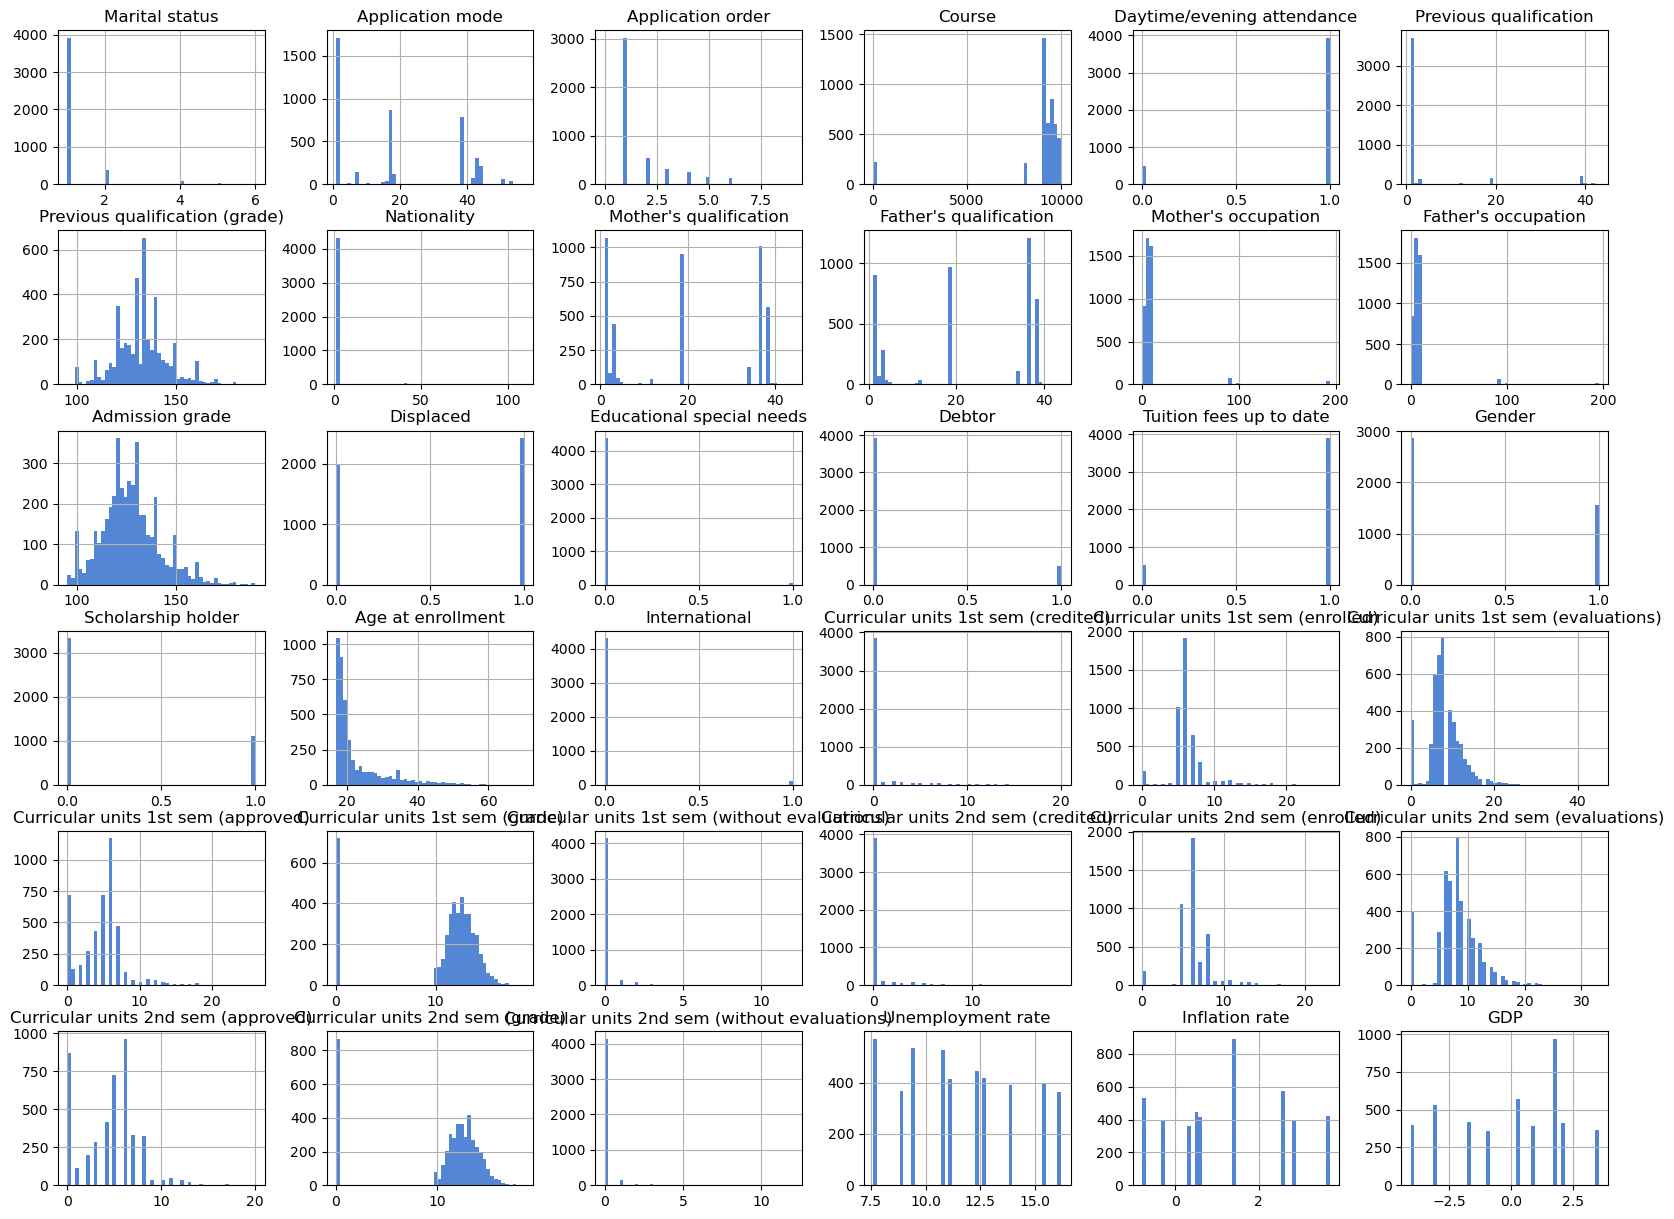

In [11]:
#Show all attributes in historgram
stdData[stdData.columns].hist(bins=50, figsize=(20,15), color='#5486d6')
plt.show

# Description of each historgam attribute

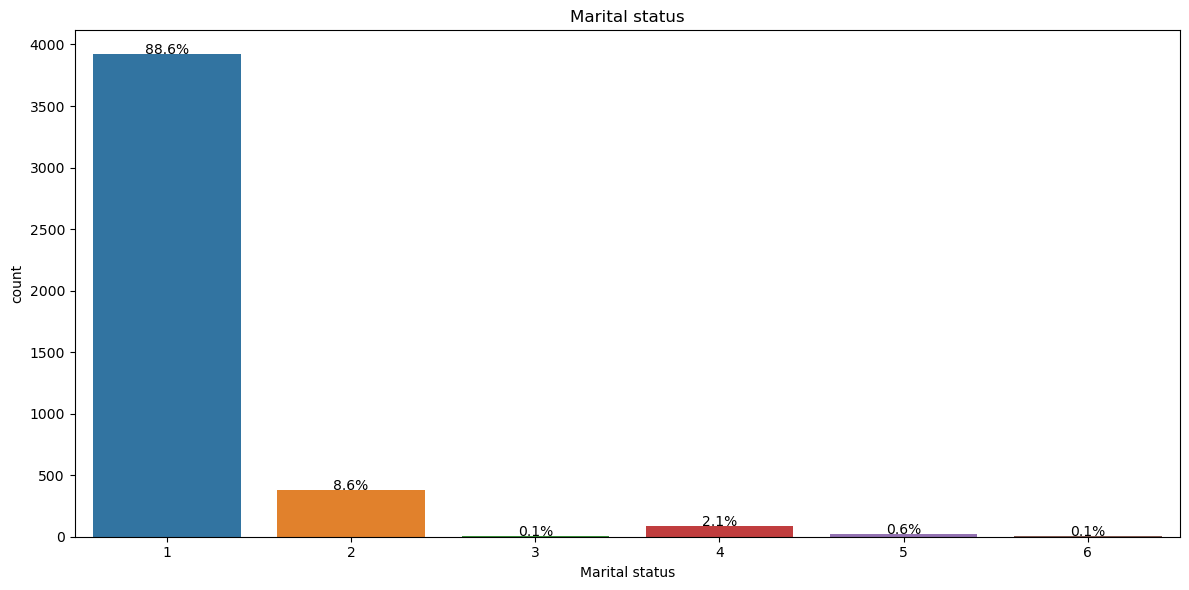

In [12]:
# Define the figure size
plt.figure(figsize=(12, 6))

# Create a countplot
ax = sns.countplot(data=stdData, x='Marital status')

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Set title
plt.title('Marital status')

# Adjust the Layout
plt.tight_layout()

# Show the plot
plt.show()


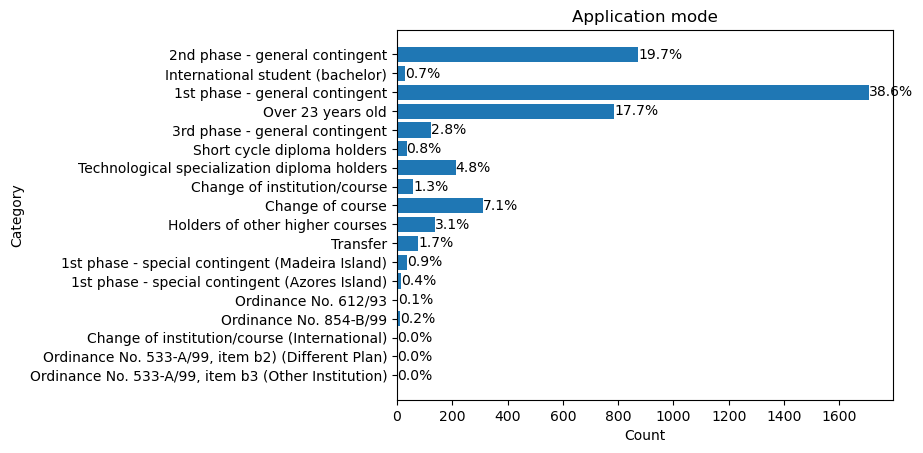

In [13]:
# Mapping of numbers to categories
category_mapping = {
    1: '1st phase - general contingent',
    2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)',
    17: '2nd phase - general contingent',
    18: '3rd phase - general contingent',
    26: 'Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
    39: 'Over 23 years old',
    42: 'Transfer',
    43: 'Change of course',
    44: 'Technological specialization diploma holders',
    51: 'Change of institution/course',
    53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}

# Count the occurrences of each category in the data
category_counts = Counter(stdData["Application mode"])

# Extract category labels and counts
category_labels = [category_mapping[key] for key in category_counts.keys()]
counts = list(category_counts.values())

# Create a horizontal bar chart
plt.barh(category_labels, counts)

# Add percentage labels to each bar
for index, value in enumerate(counts):
    plt.text(value, index, f'{value/sum(counts)*100:.1f}%', ha='left', va='center')


# Add labels and title
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Application mode')

# Display the chart
plt.gca().invert_yaxis()  # Invert the y-axis to display categories from top to bottom
plt.show()


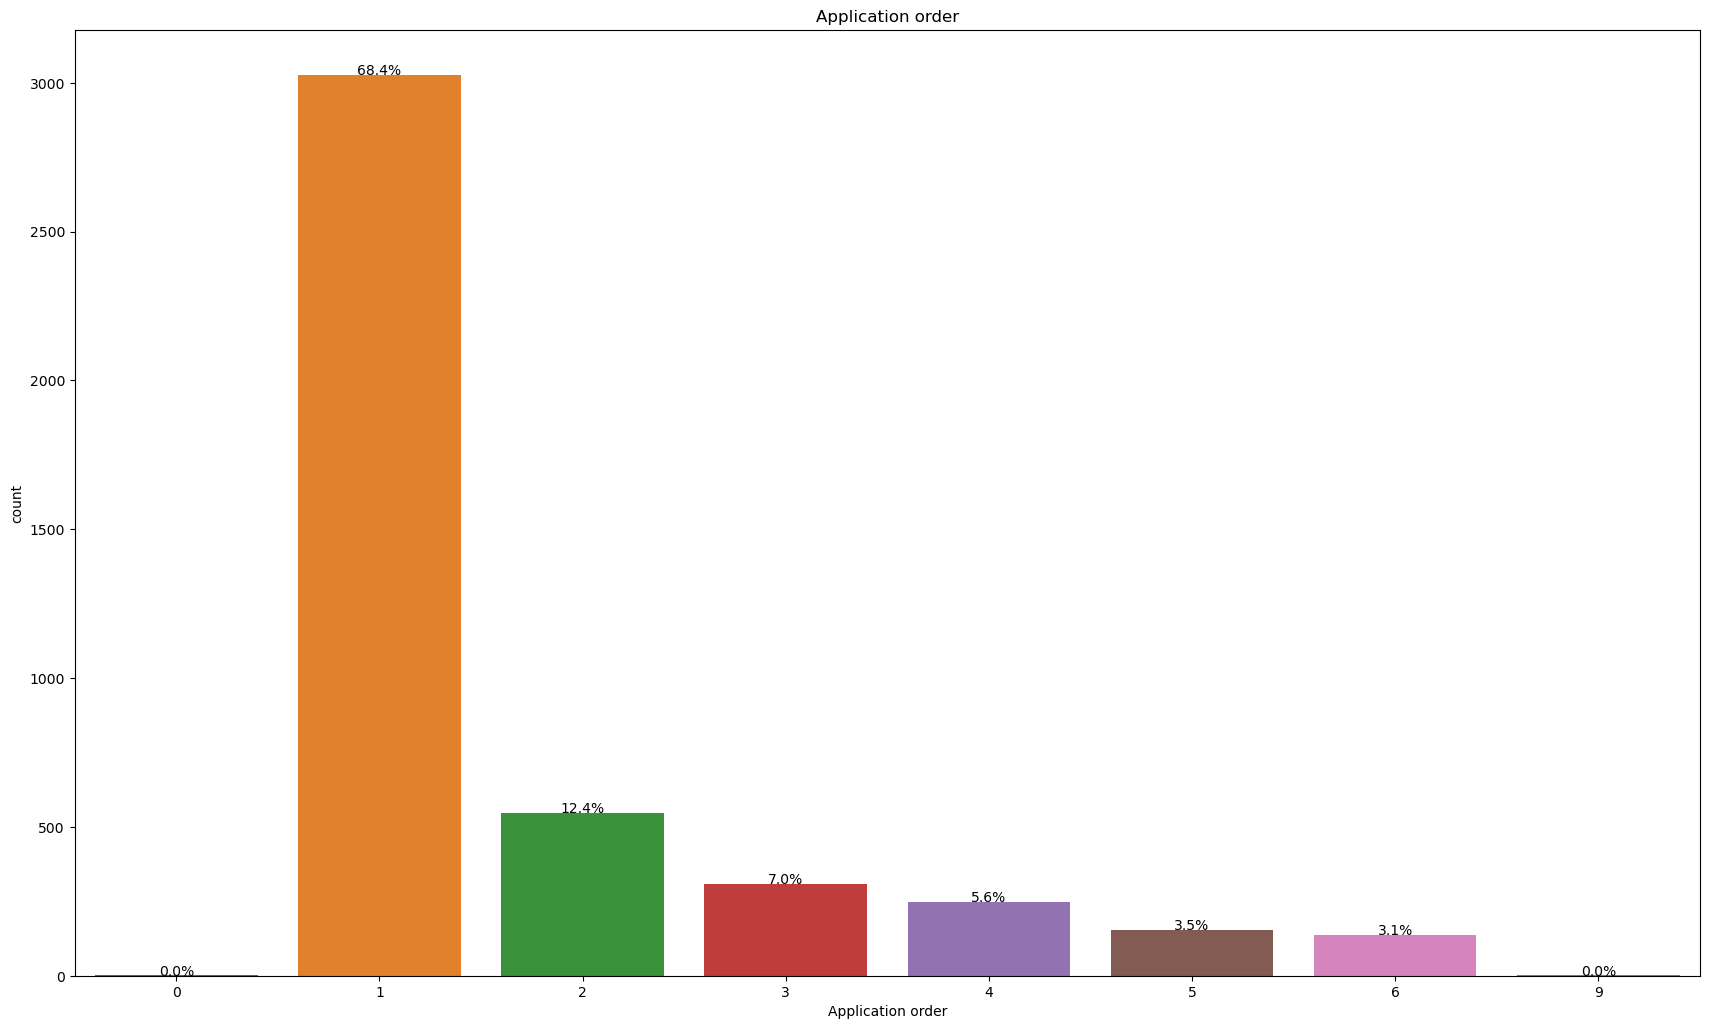

In [14]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x='Application order') 
plt.title('Application order') 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')



#Adjust the Layout
plt.tight_layout()

# Show the plots
plt.show()

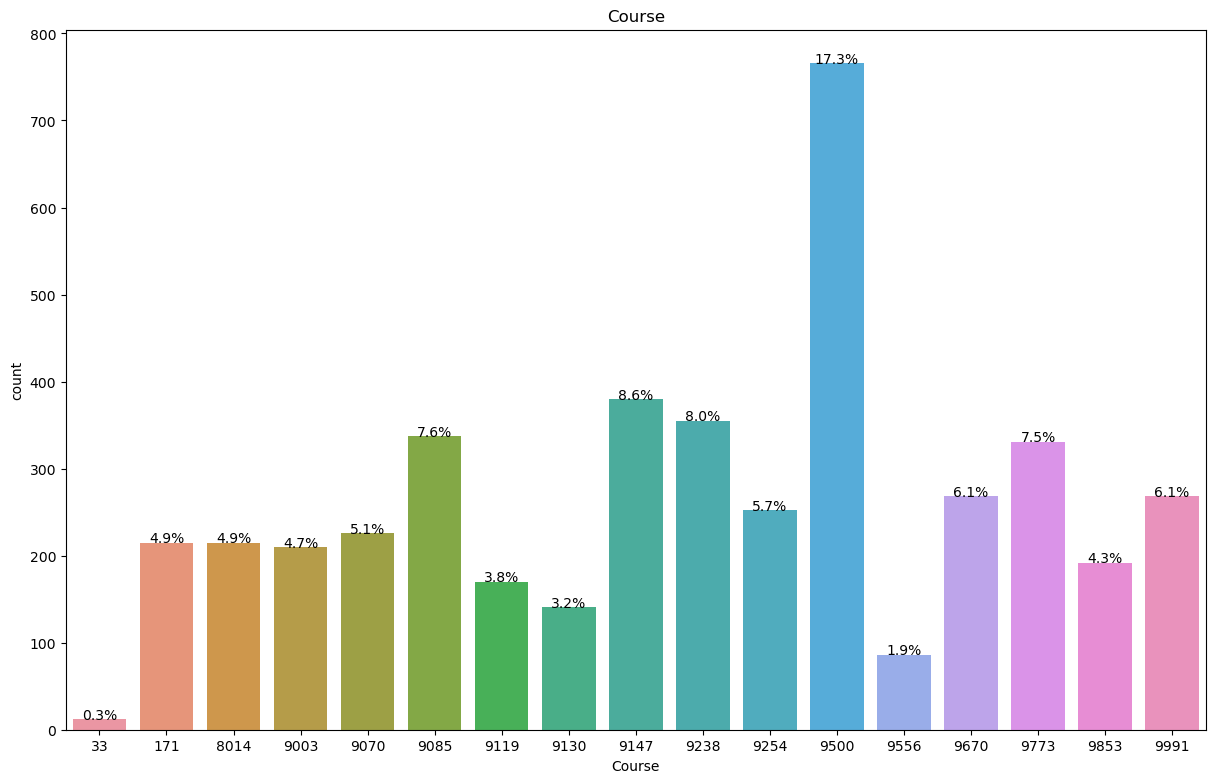

In [15]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x='Course') #x change to the attribute you want to test
plt.title('Course') #the title of your histogram

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')


# Show the plots
plt.show()

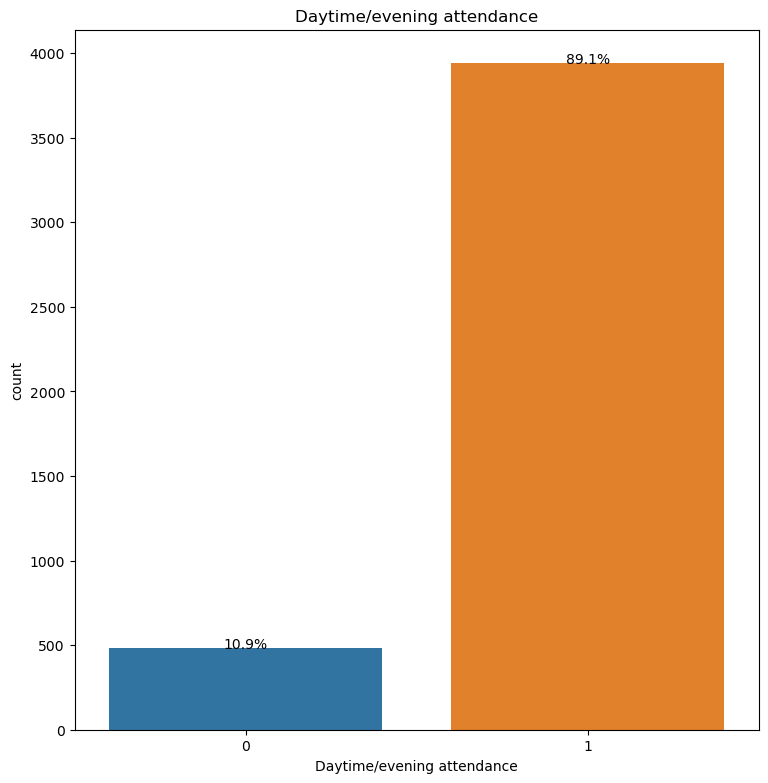

In [16]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Daytime/evening attendance")
plt.title('Daytime/evening attendance')

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')


# Show the plots
plt.show()

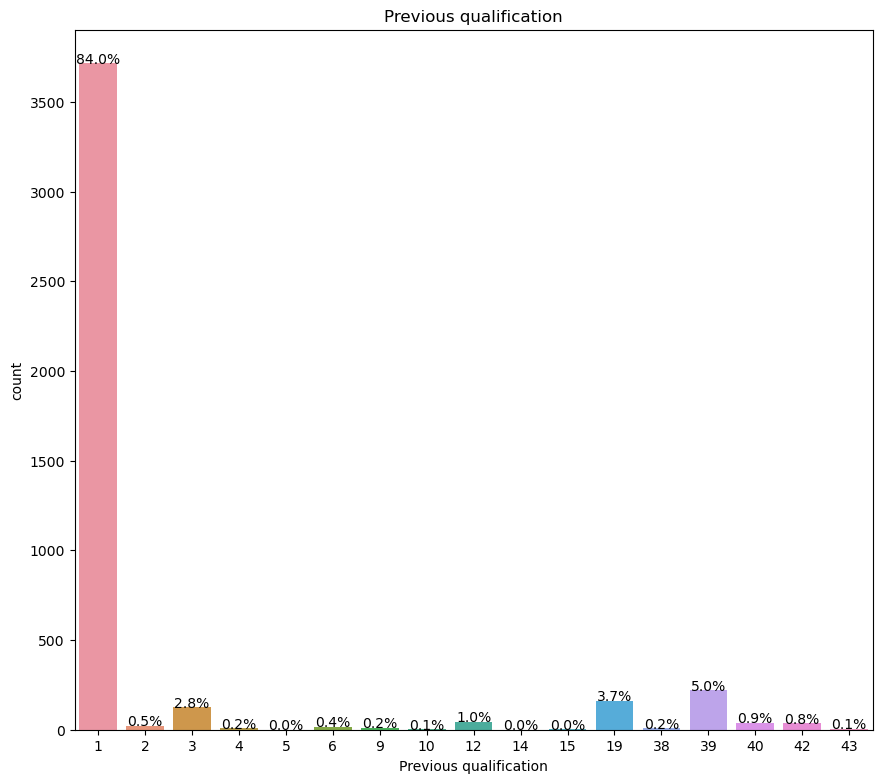

In [17]:
# Define the figure size

plt.figure(figsize=(35,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x='Previous qualification') 
plt.title('Previous qualification') 


# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

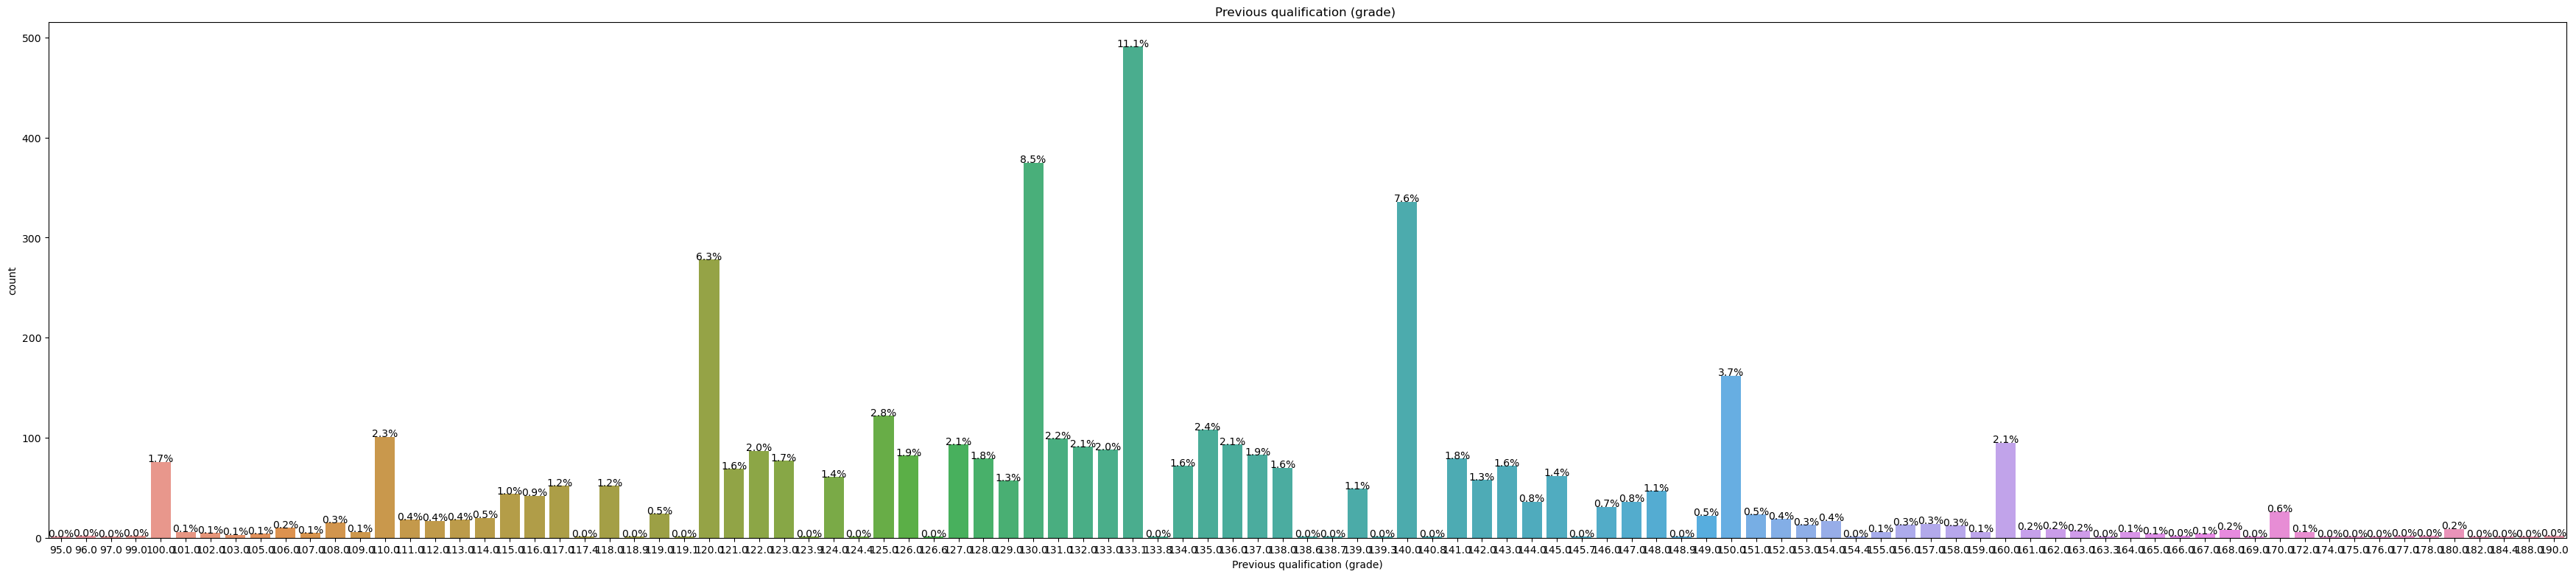

In [18]:
# Define the figure size

plt.figure(figsize=(150,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x= "Previous qualification (grade)") 
plt.title('Previous qualification (grade) ') 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')


# Show the plots
plt.show()

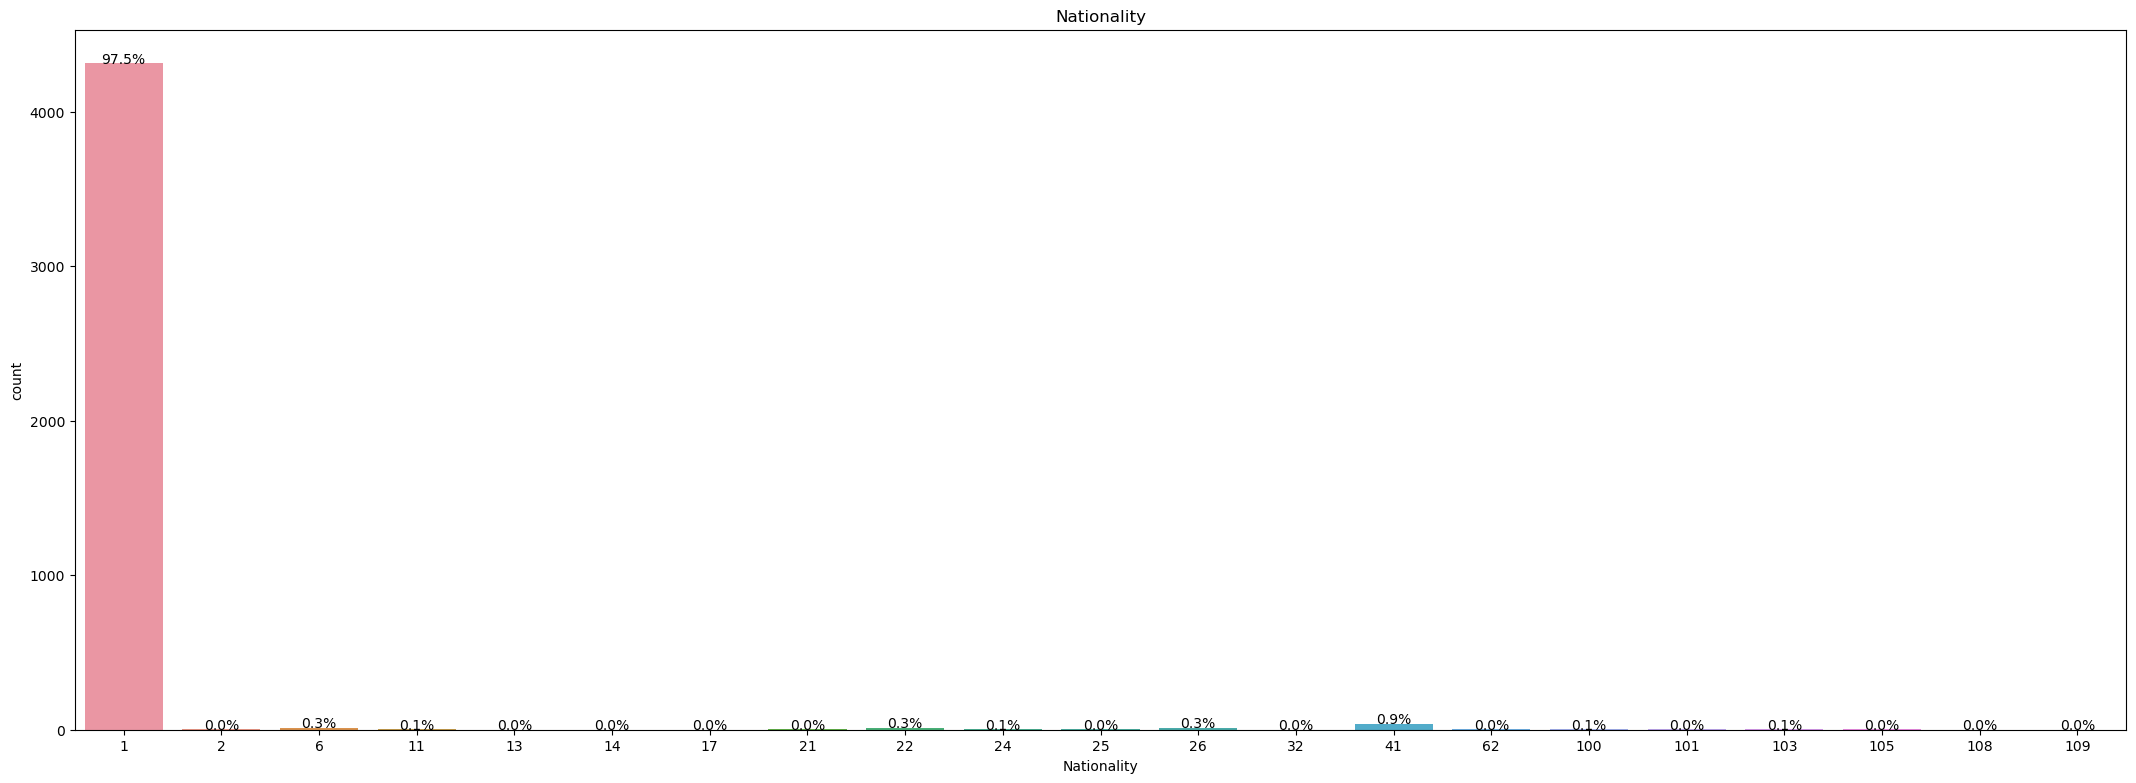

In [19]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x='Nationality') 
plt.title('Nationality') 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

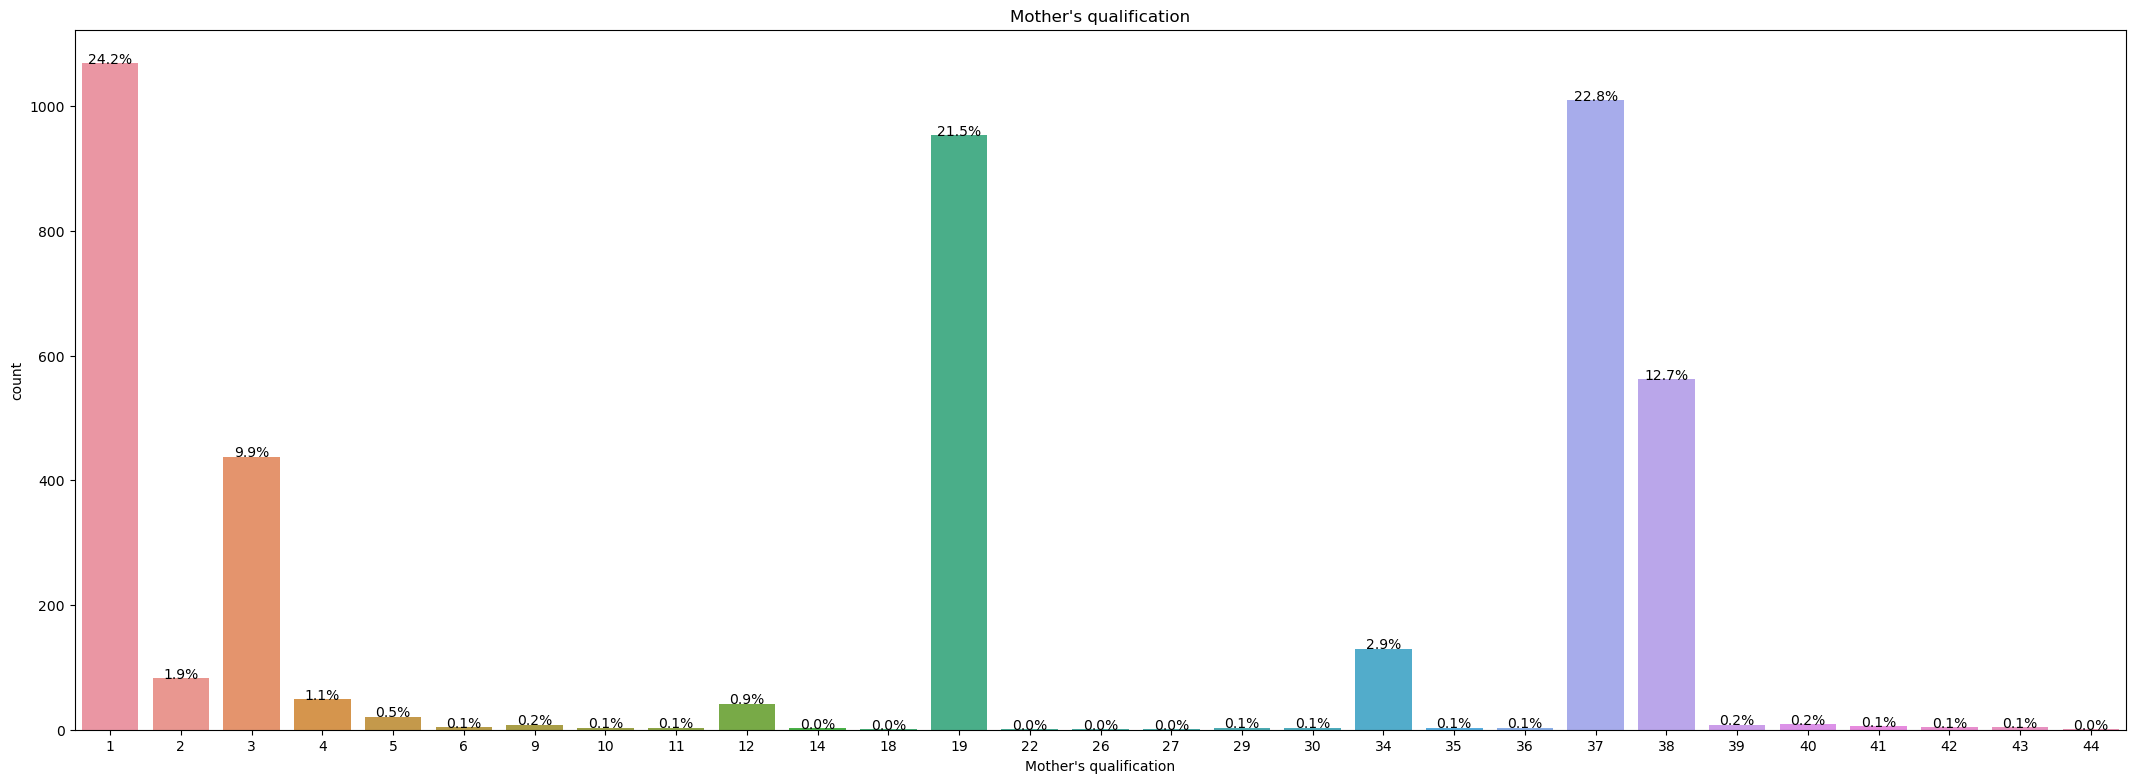

In [20]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Mother's qualification") 
plt.title("Mother's qualification") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

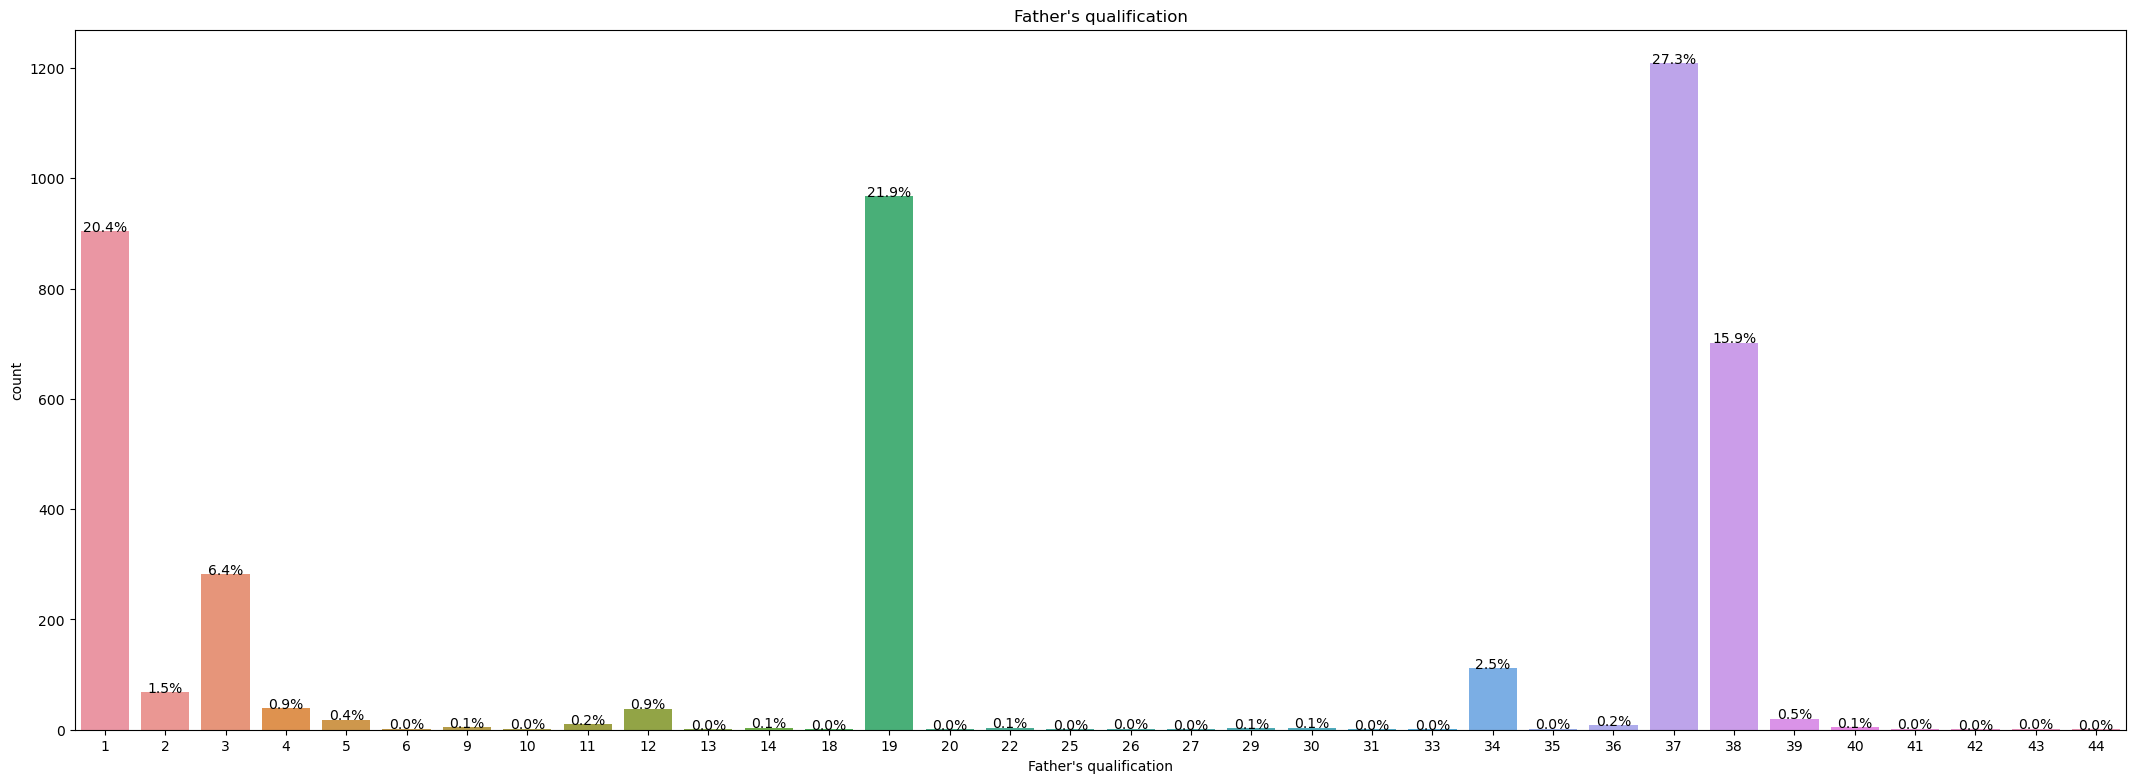

In [21]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Father's qualification") 
plt.title("Father's qualification") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

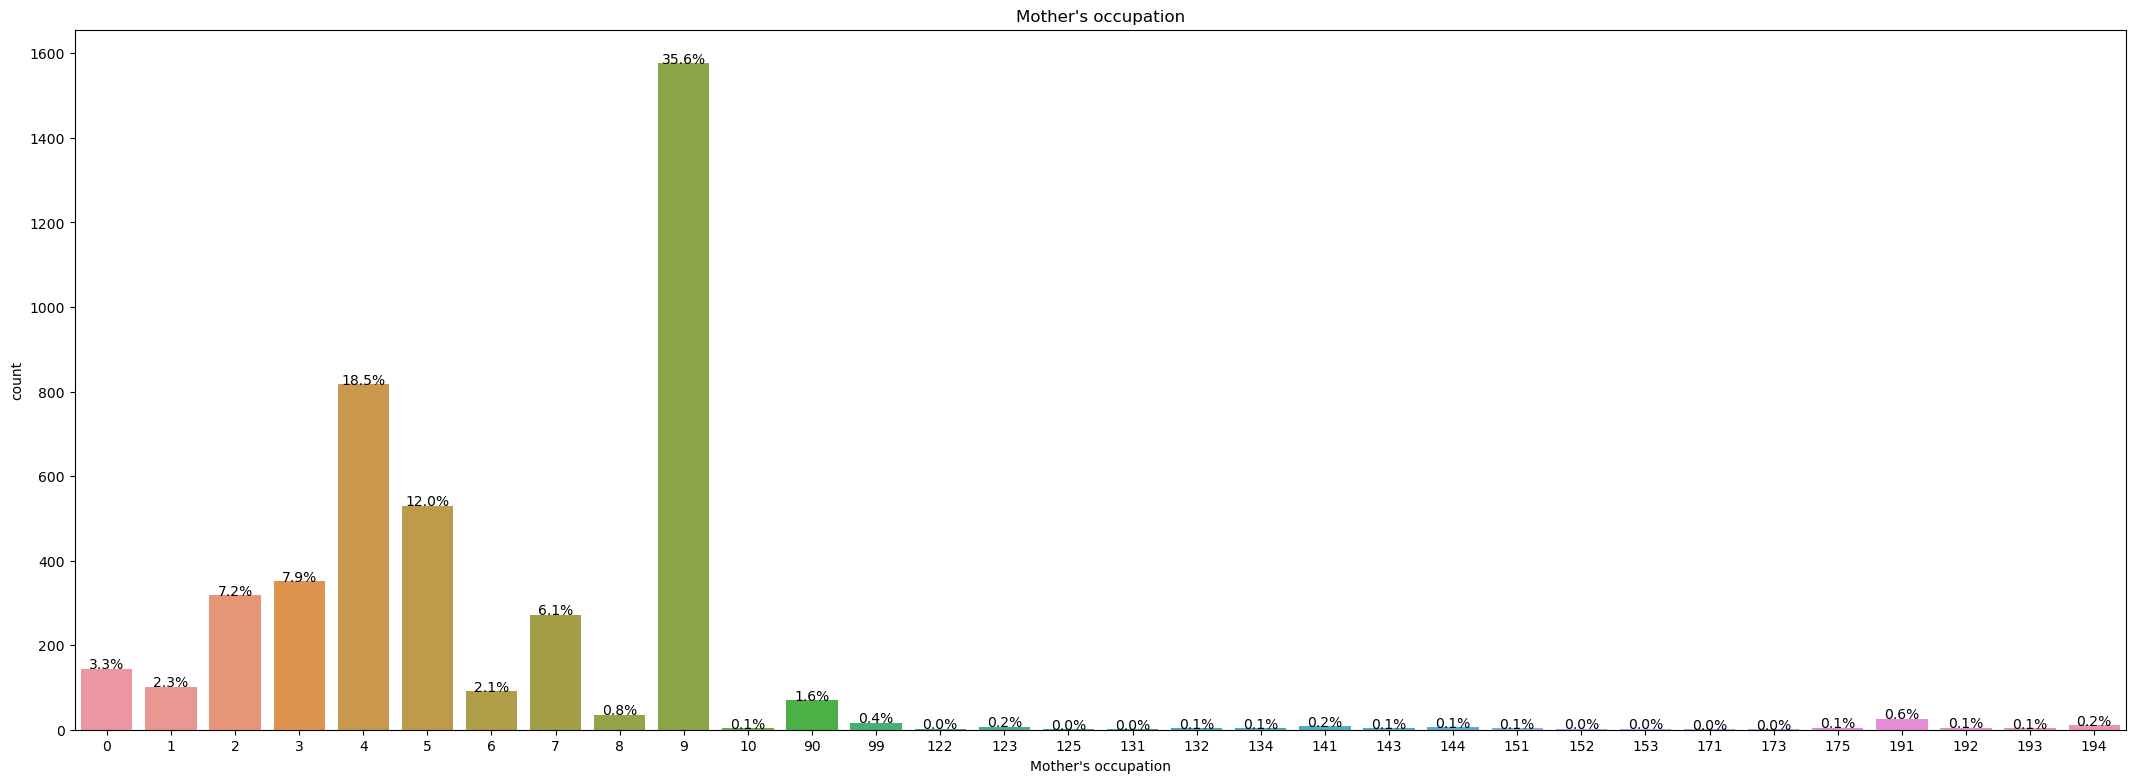

In [22]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Mother's occupation") 
plt.title("Mother's occupation") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

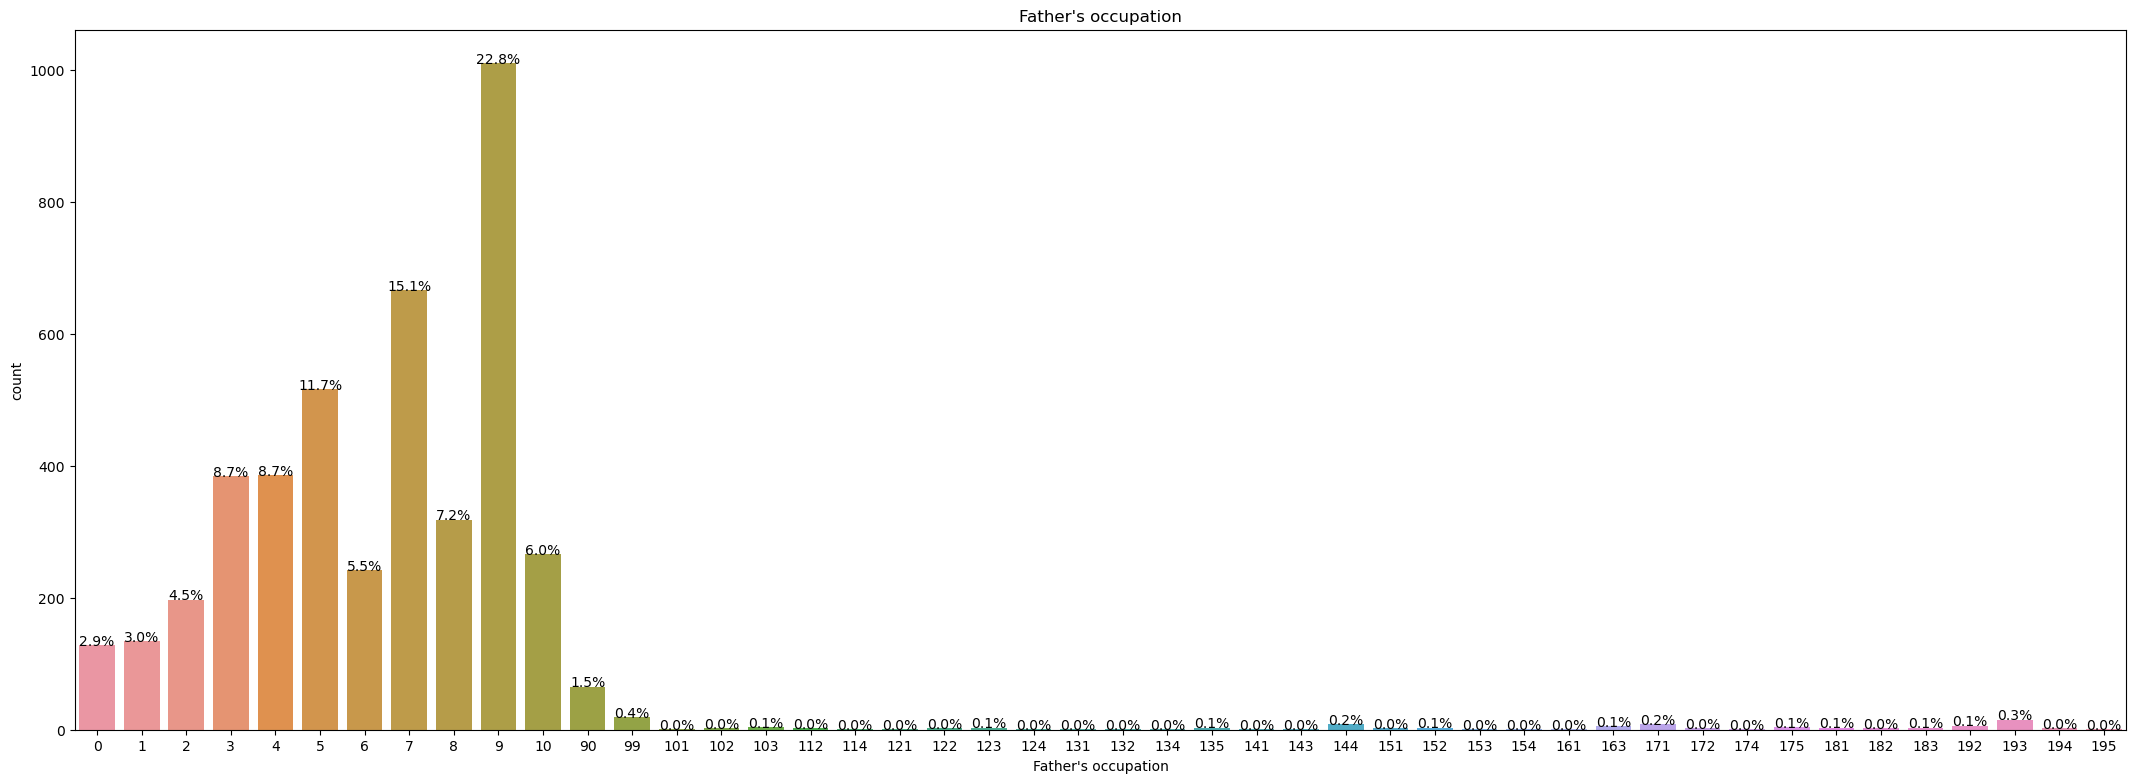

In [23]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Father's occupation") 
plt.title("Father's occupation") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

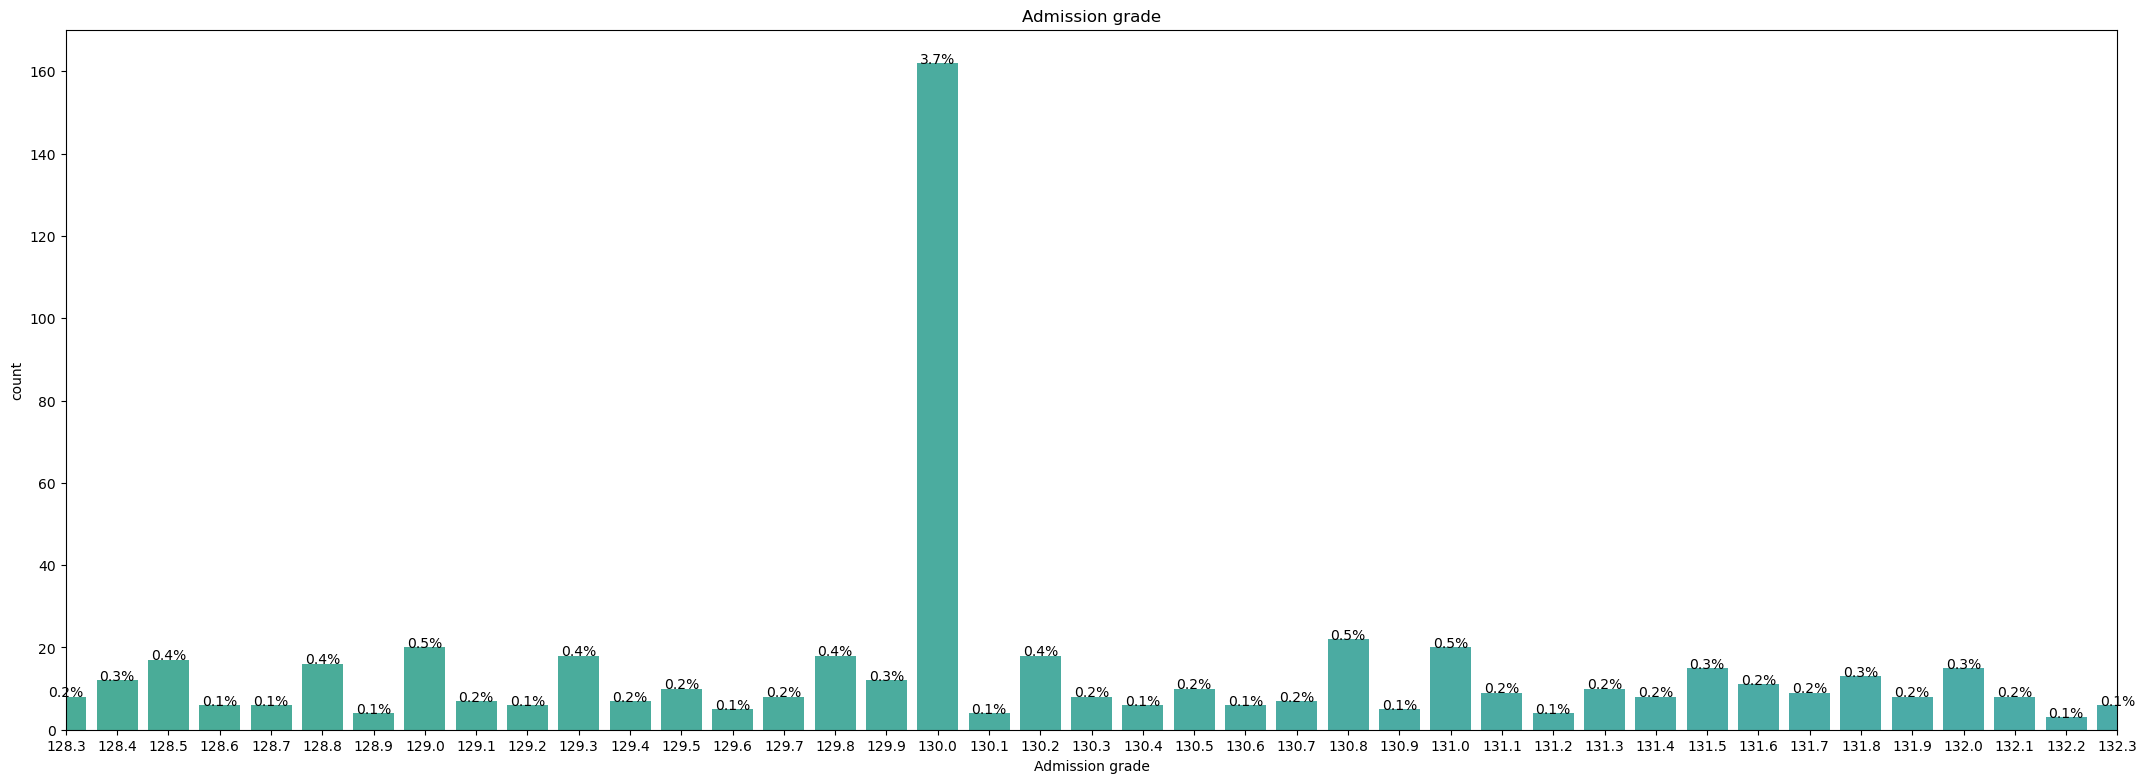

In [24]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Admission grade") 
plt.title("Admission grade") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

#Zoom in 
zoomed_in_range = (280, 320)
plt.xlim(zoomed_in_range)

    
# Show the plots
plt.show()

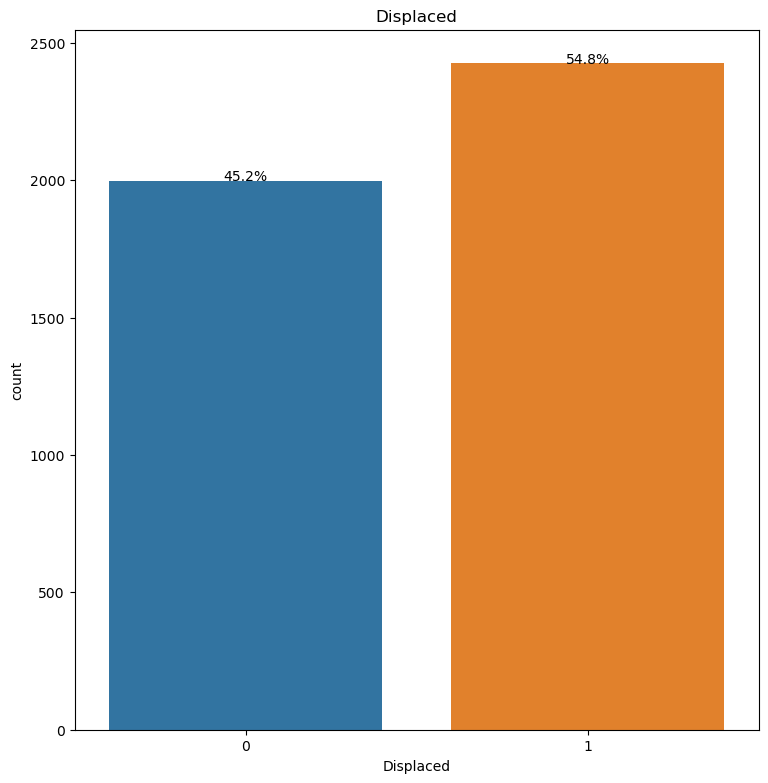

In [25]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Displaced") 
plt.title("Displaced") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

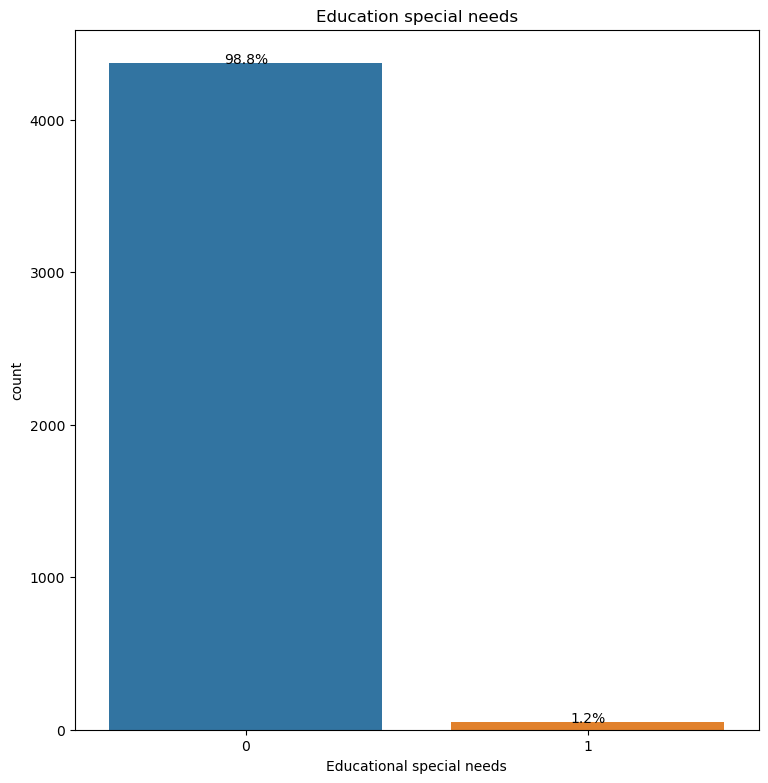

In [26]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Educational special needs") 
plt.title("Education special needs") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

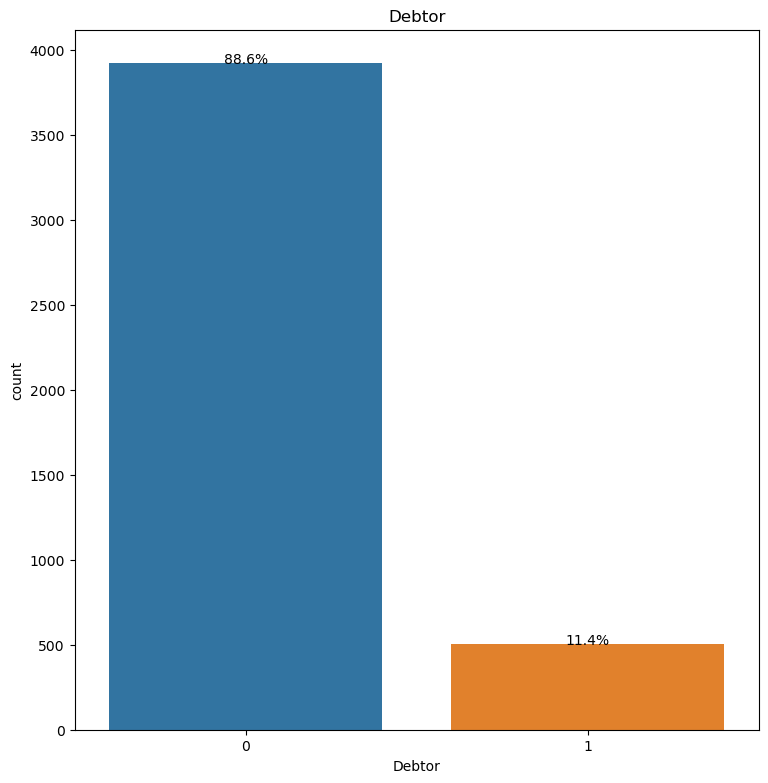

In [27]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Debtor") 
plt.title("Debtor") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

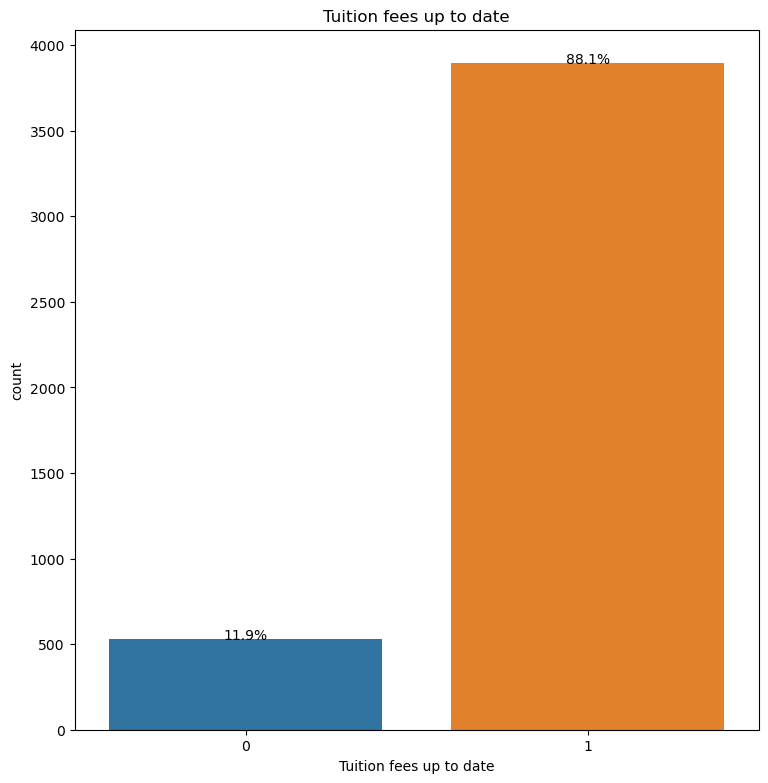

In [28]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Tuition fees up to date") 
plt.title("Tuition fees up to date") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

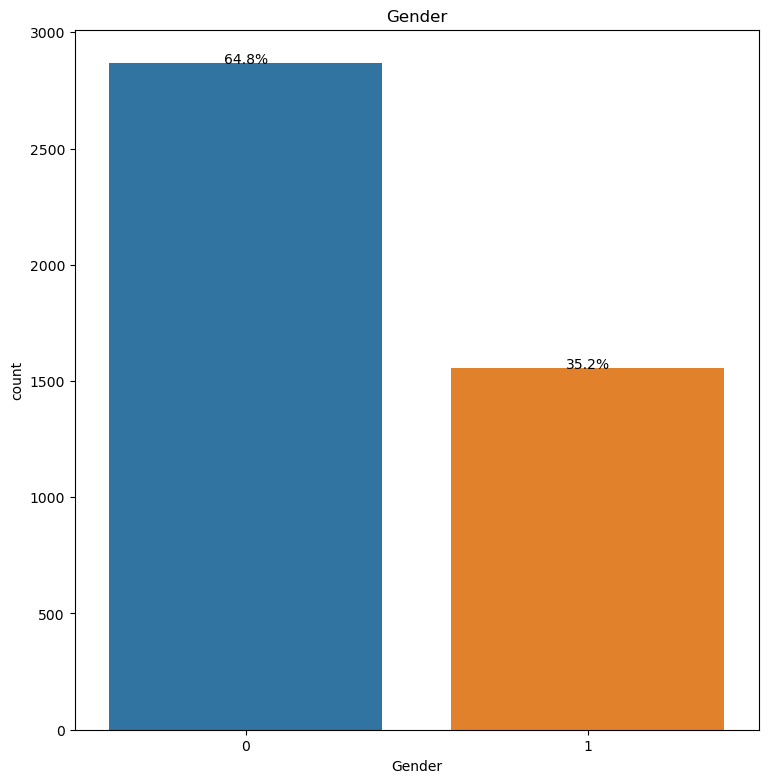

In [29]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Gender") 
plt.title("Gender") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

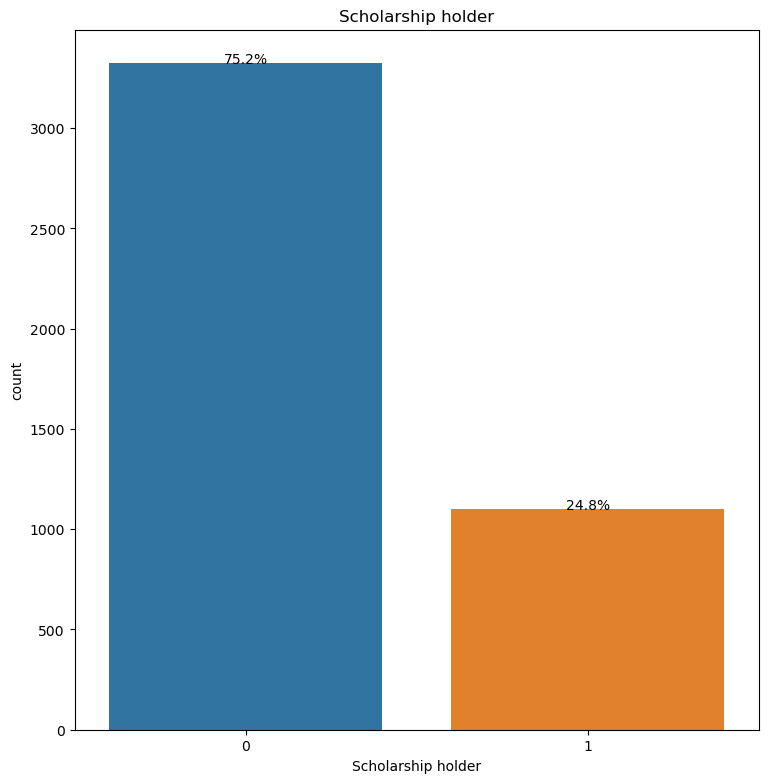

In [30]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Scholarship holder") 
plt.title("Scholarship holder") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

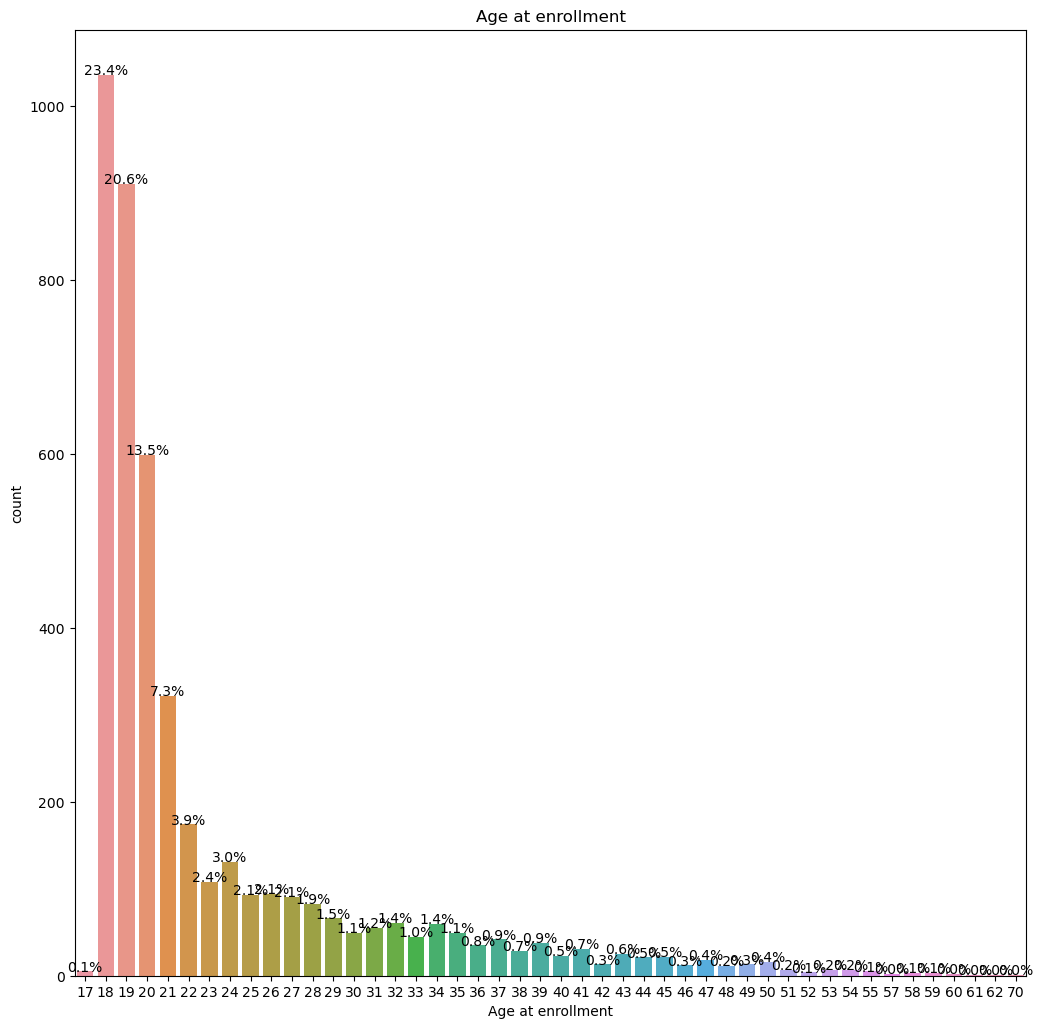

In [31]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Age at enrollment") 
plt.title("Age at enrollment") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

plt.tight_layout()

# Show the plots
plt.show()

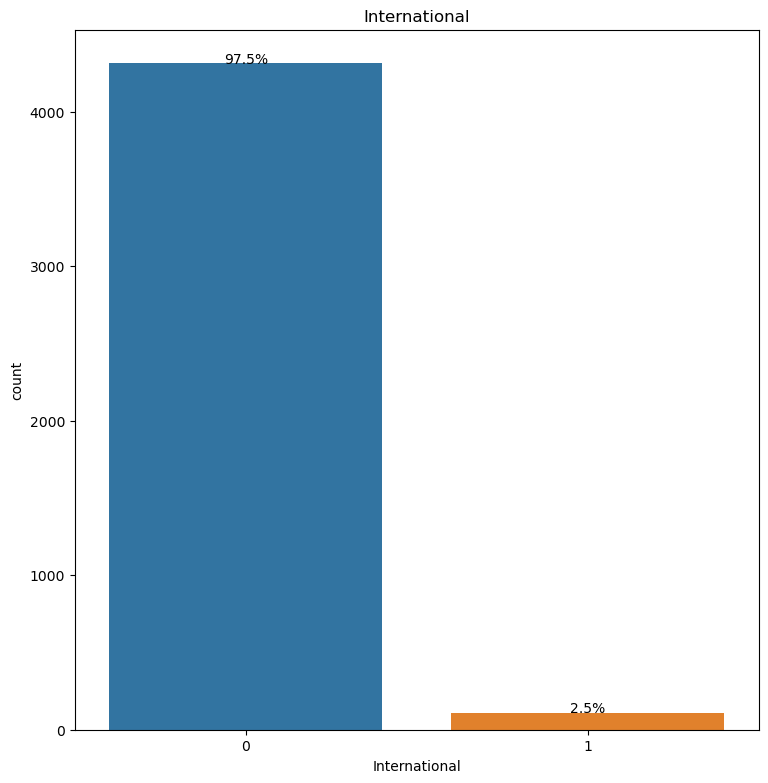

In [32]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="International") 
plt.title("International") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

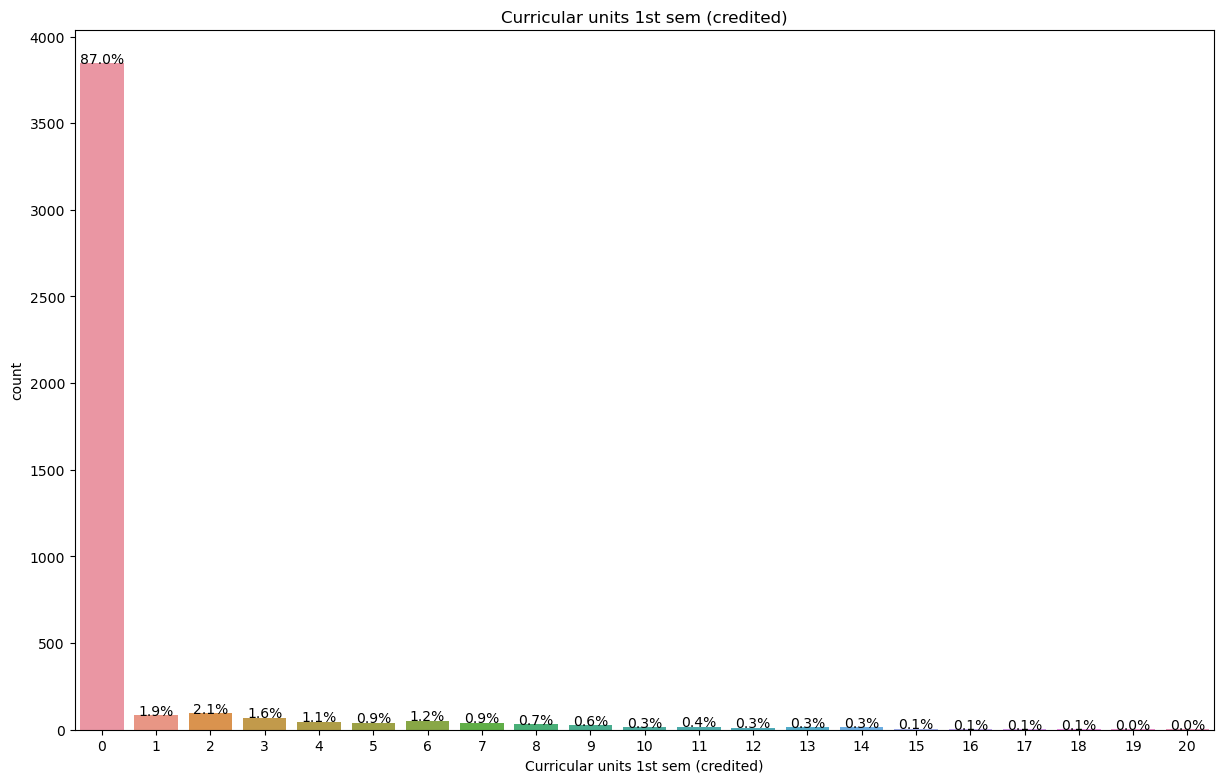

In [33]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 1st sem (credited)") 
plt.title("Curricular units 1st sem (credited)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

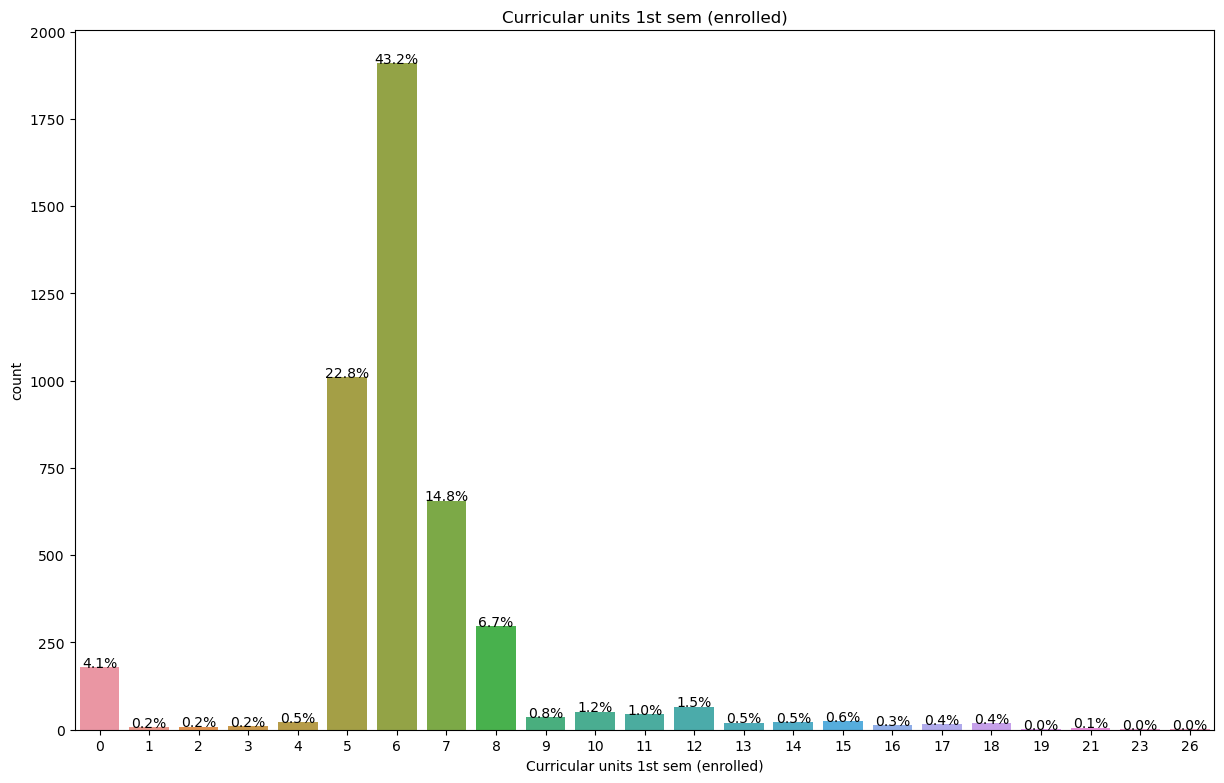

In [34]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 1st sem (enrolled)") 
plt.title("Curricular units 1st sem (enrolled)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

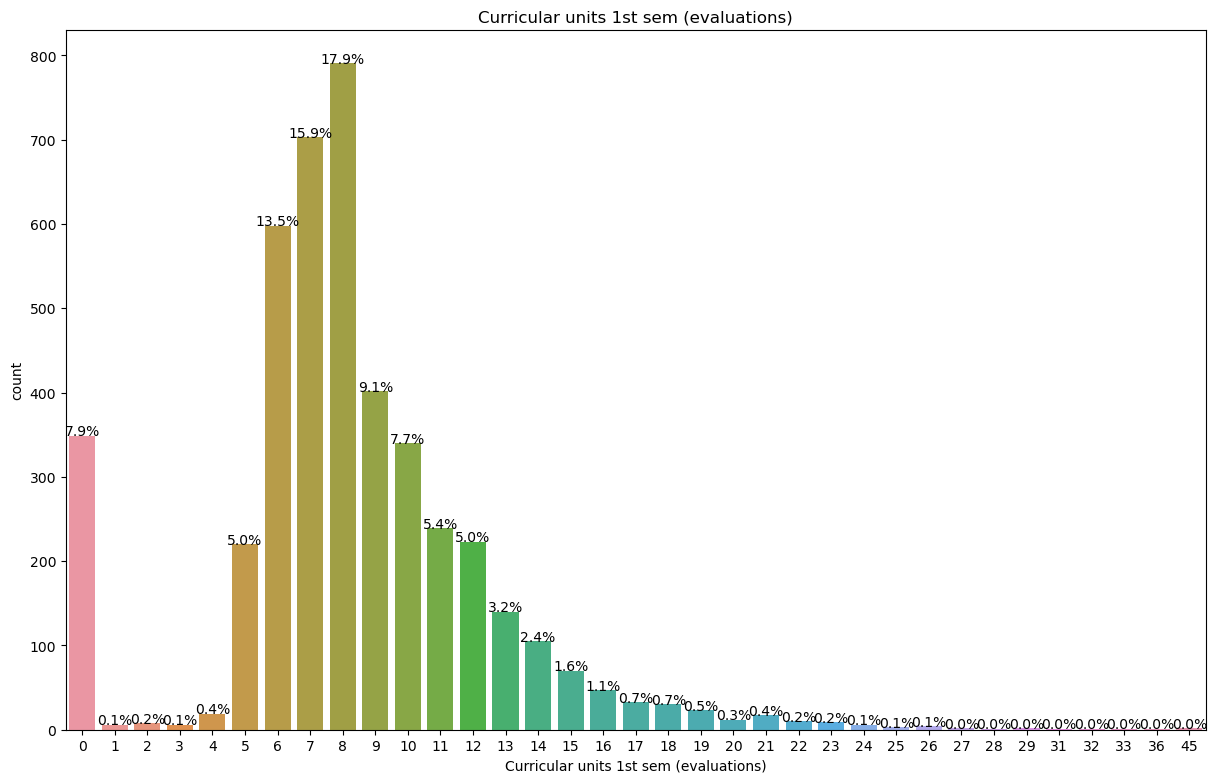

In [35]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 1st sem (evaluations)") 
plt.title("Curricular units 1st sem (evaluations)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

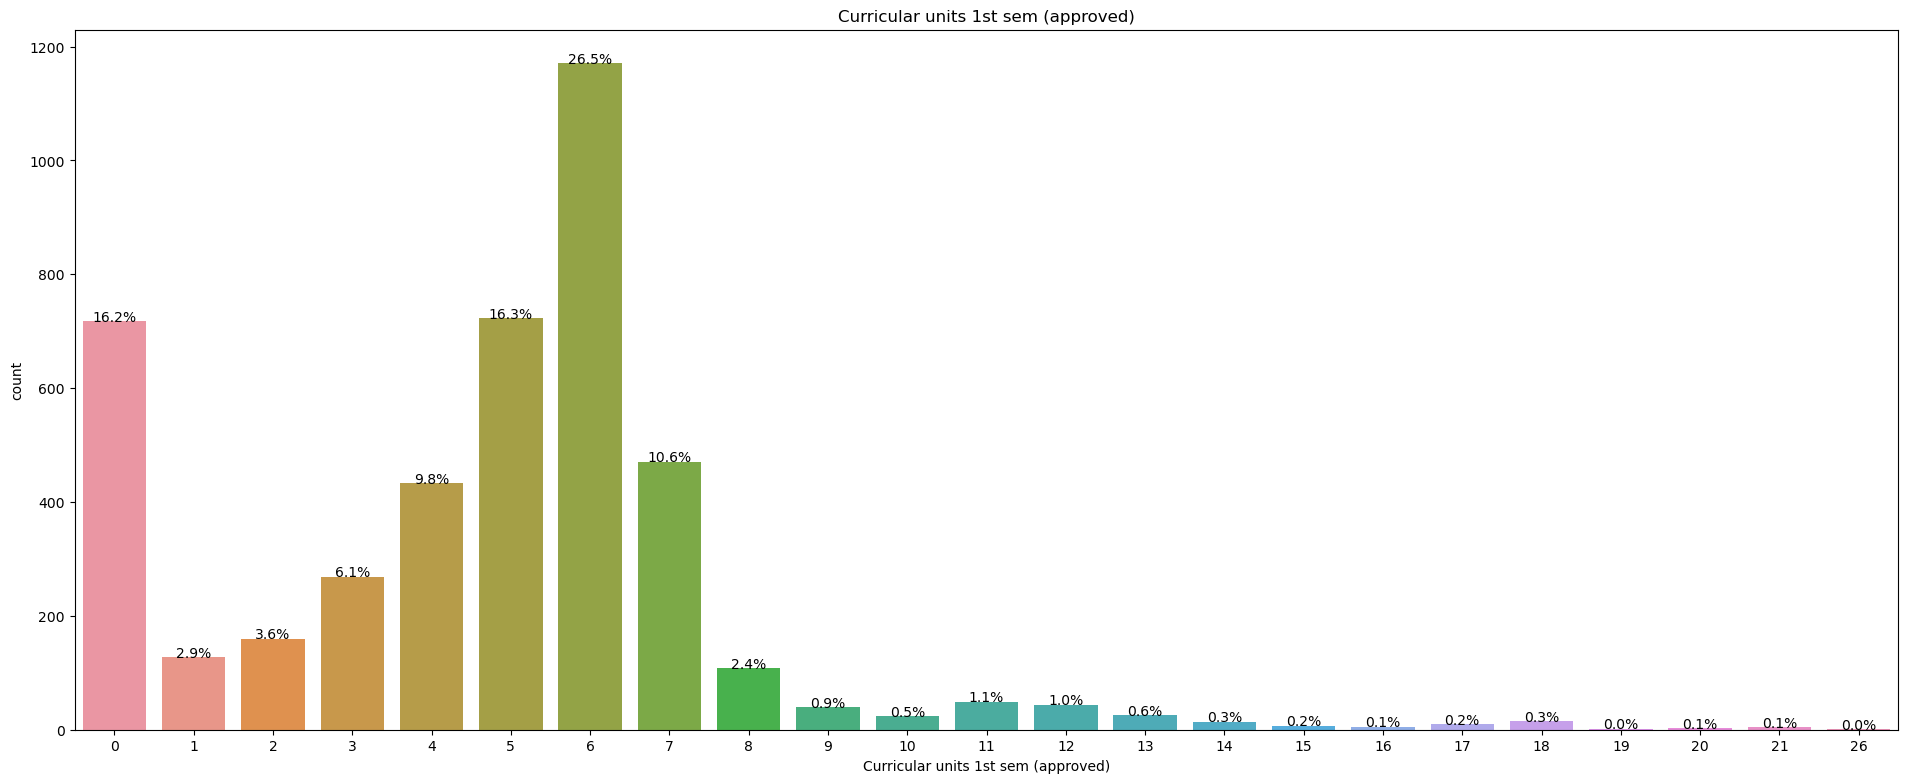

In [36]:
# Define the figure size

plt.figure(figsize=(80,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 1st sem (approved)") 
plt.title("Curricular units 1st sem (approved)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

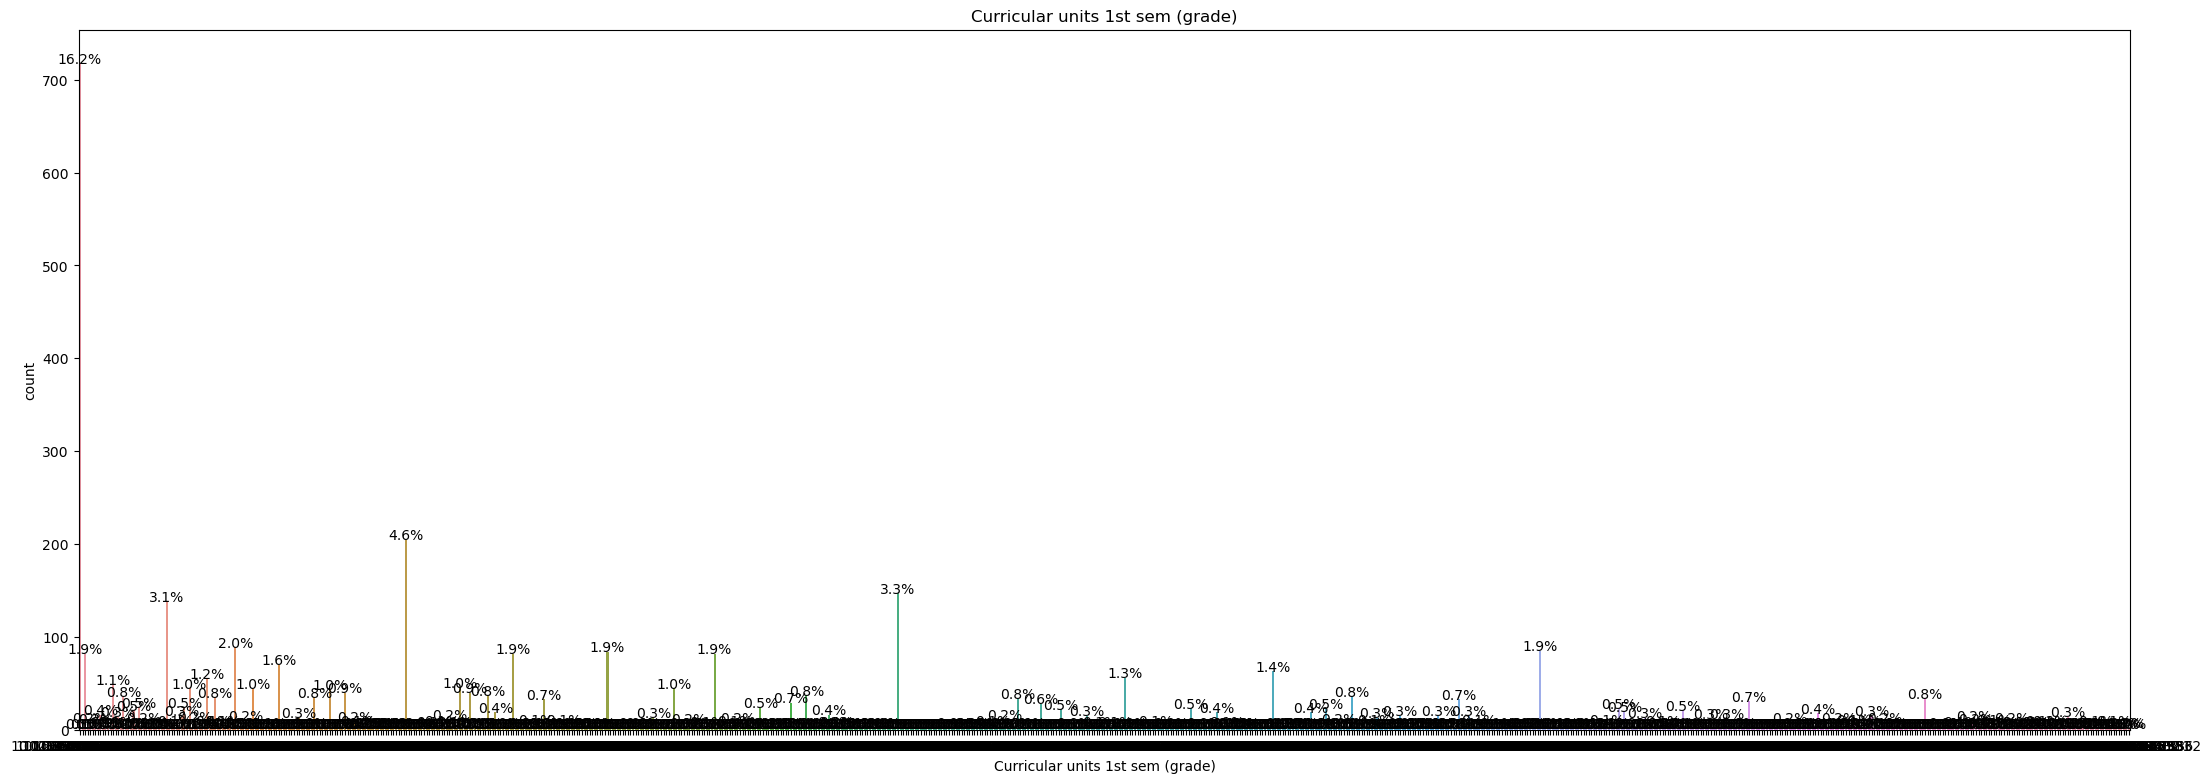

In [37]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 1st sem (grade)") 
plt.title("Curricular units 1st sem (grade)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

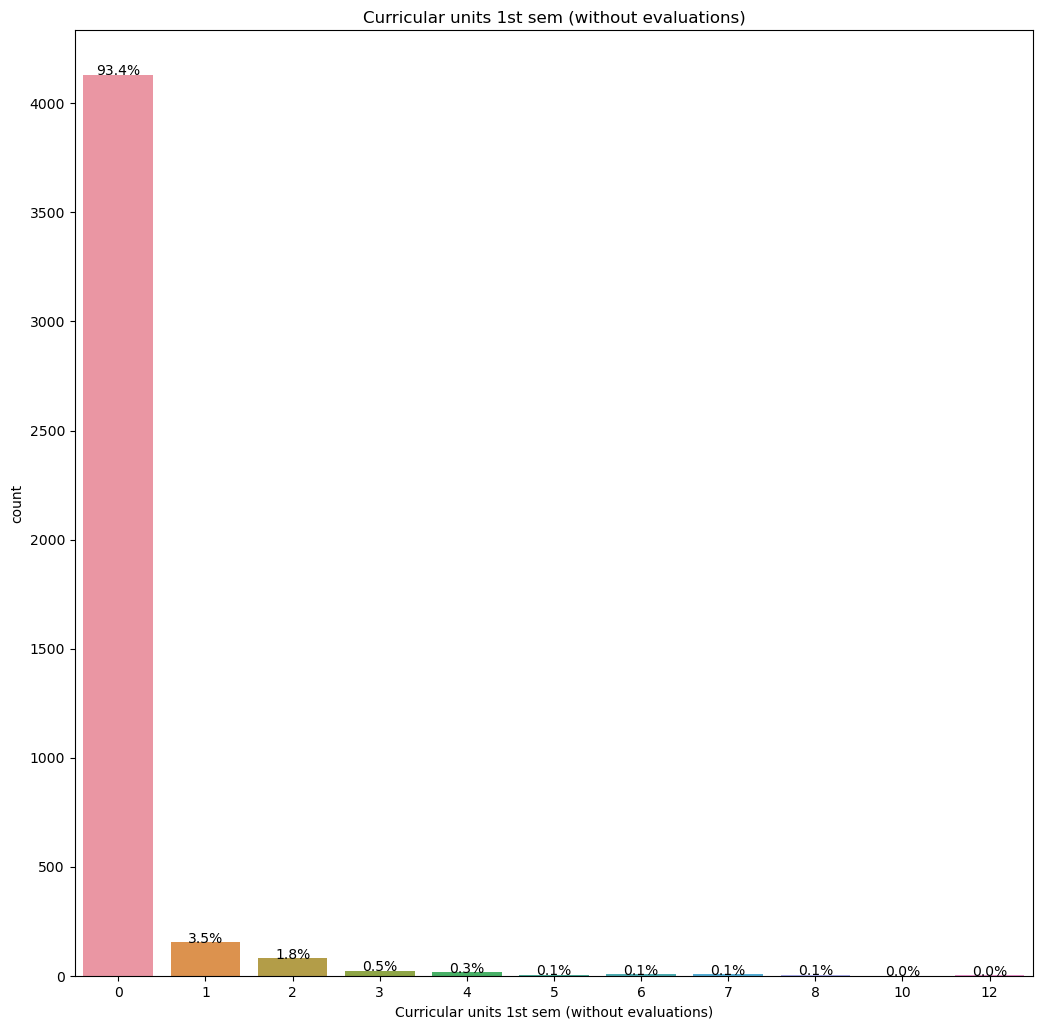

In [38]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData,x="Curricular units 1st sem (without evaluations)") 
plt.title("Curricular units 1st sem (without evaluations)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

plt.tight_layout()

# Show the plots
plt.show()

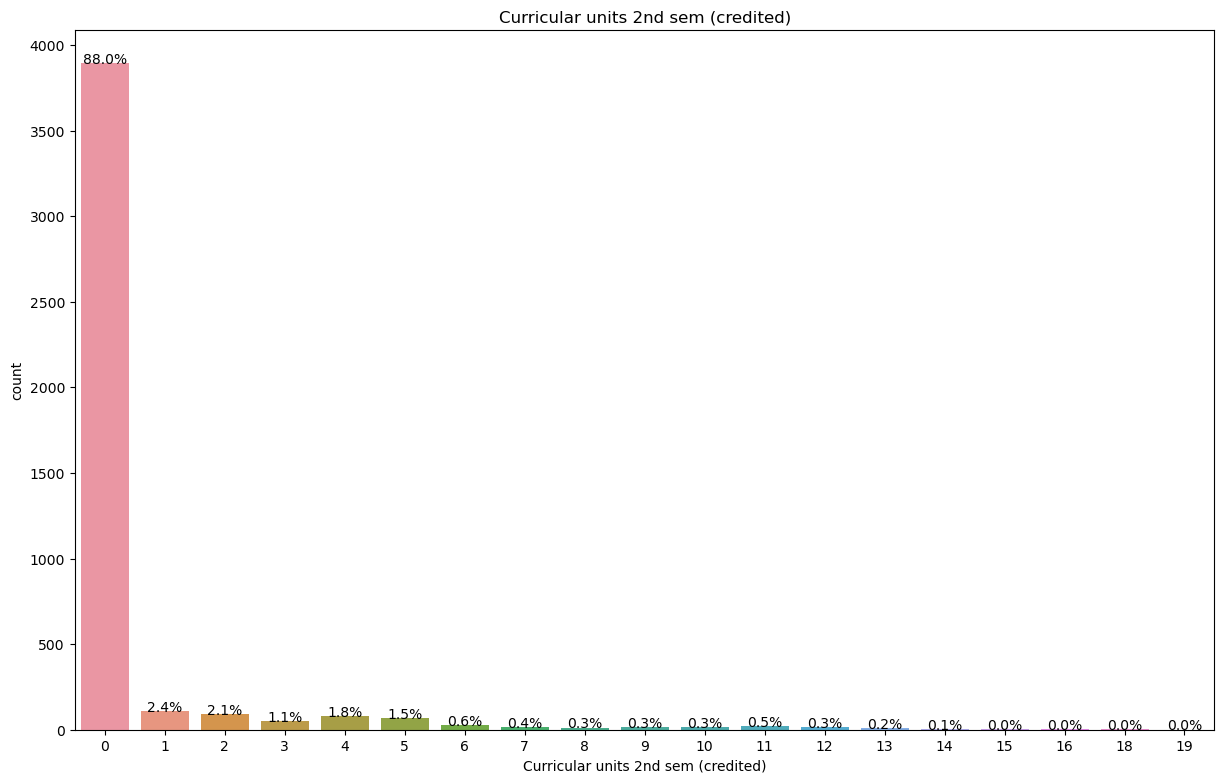

In [39]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (credited)") 
plt.title("Curricular units 2nd sem (credited)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

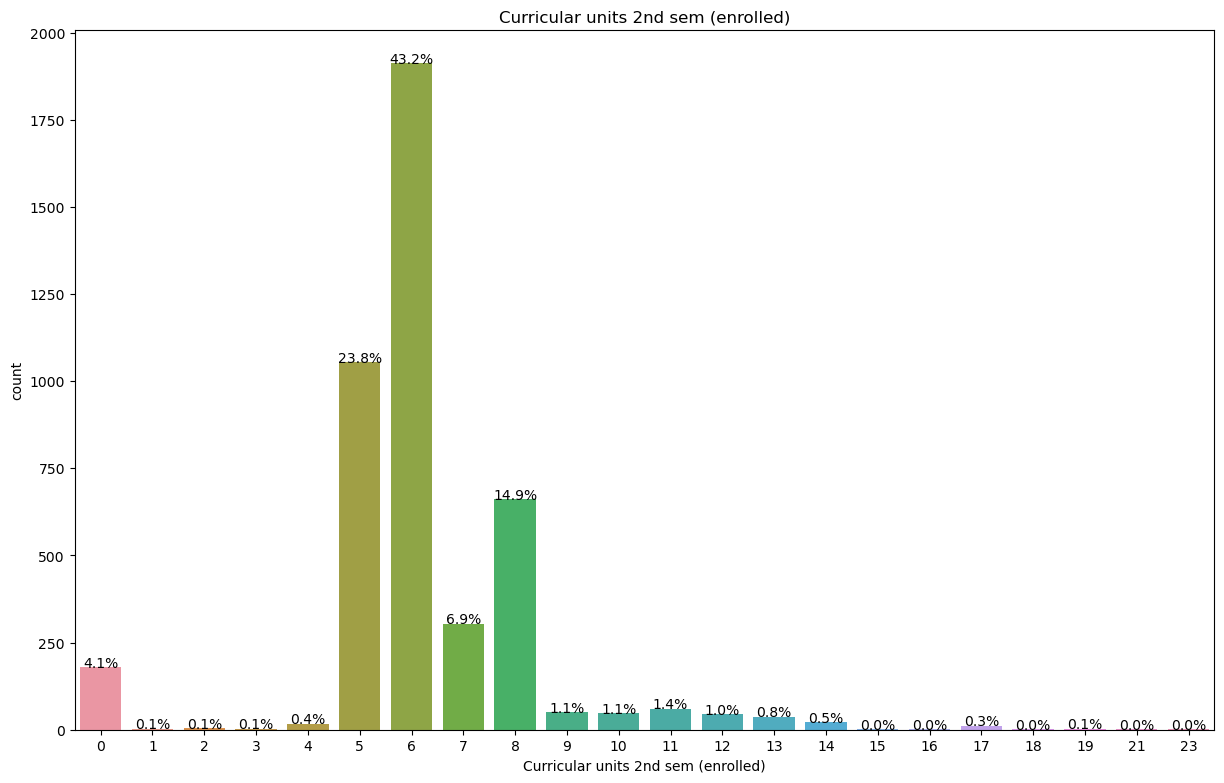

In [40]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (enrolled)") 
plt.title("Curricular units 2nd sem (enrolled)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

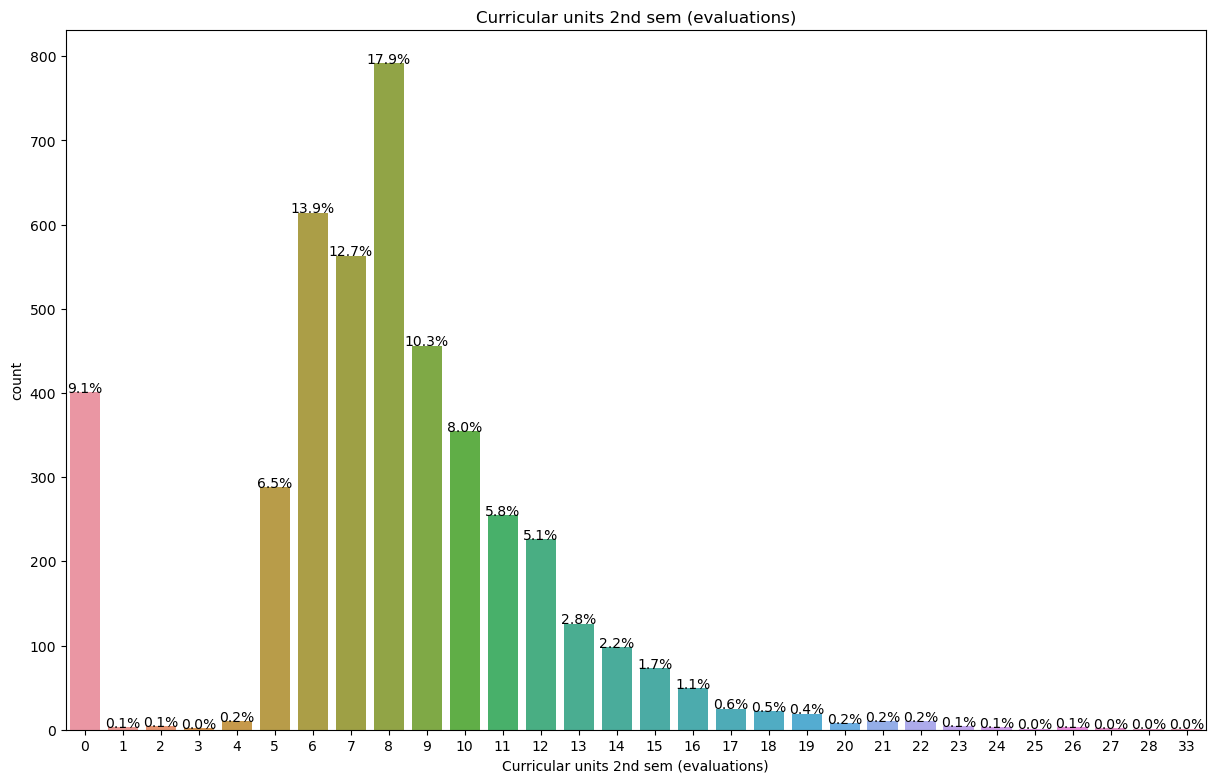

In [41]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (evaluations)") 
plt.title("Curricular units 2nd sem (evaluations)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

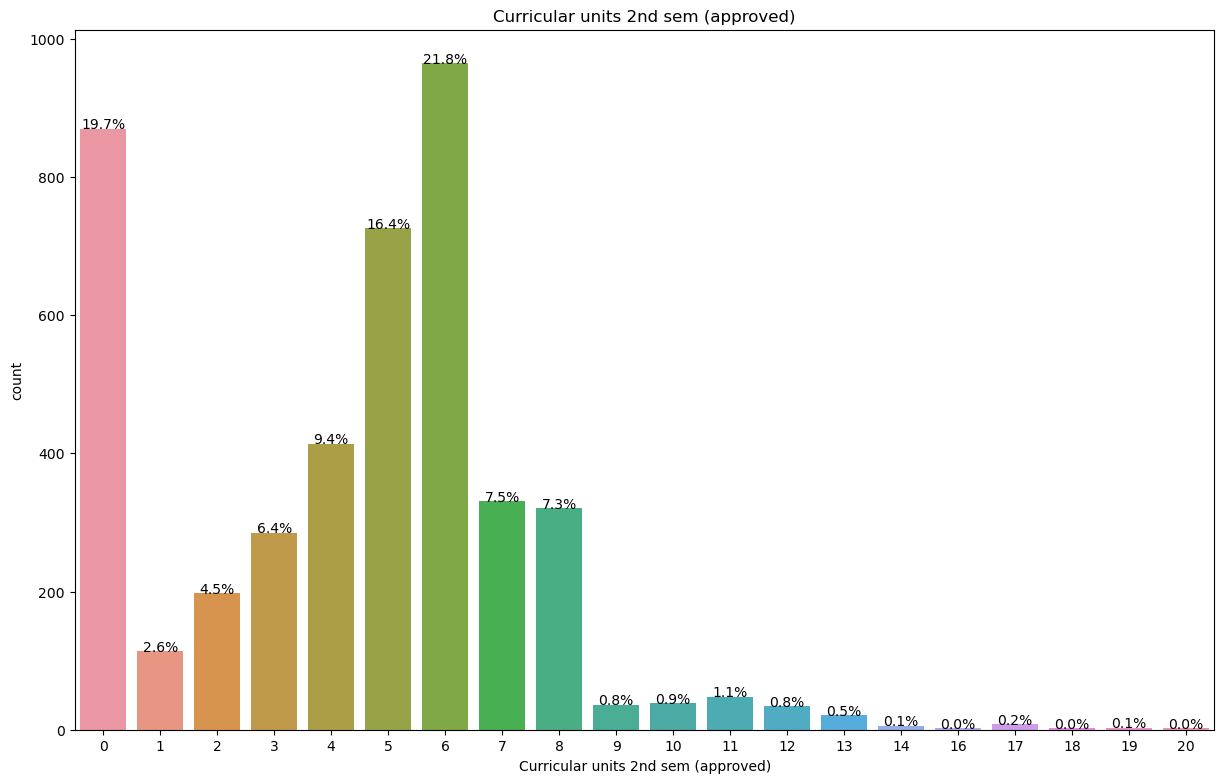

In [42]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (approved)") 
plt.title("Curricular units 2nd sem (approved)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

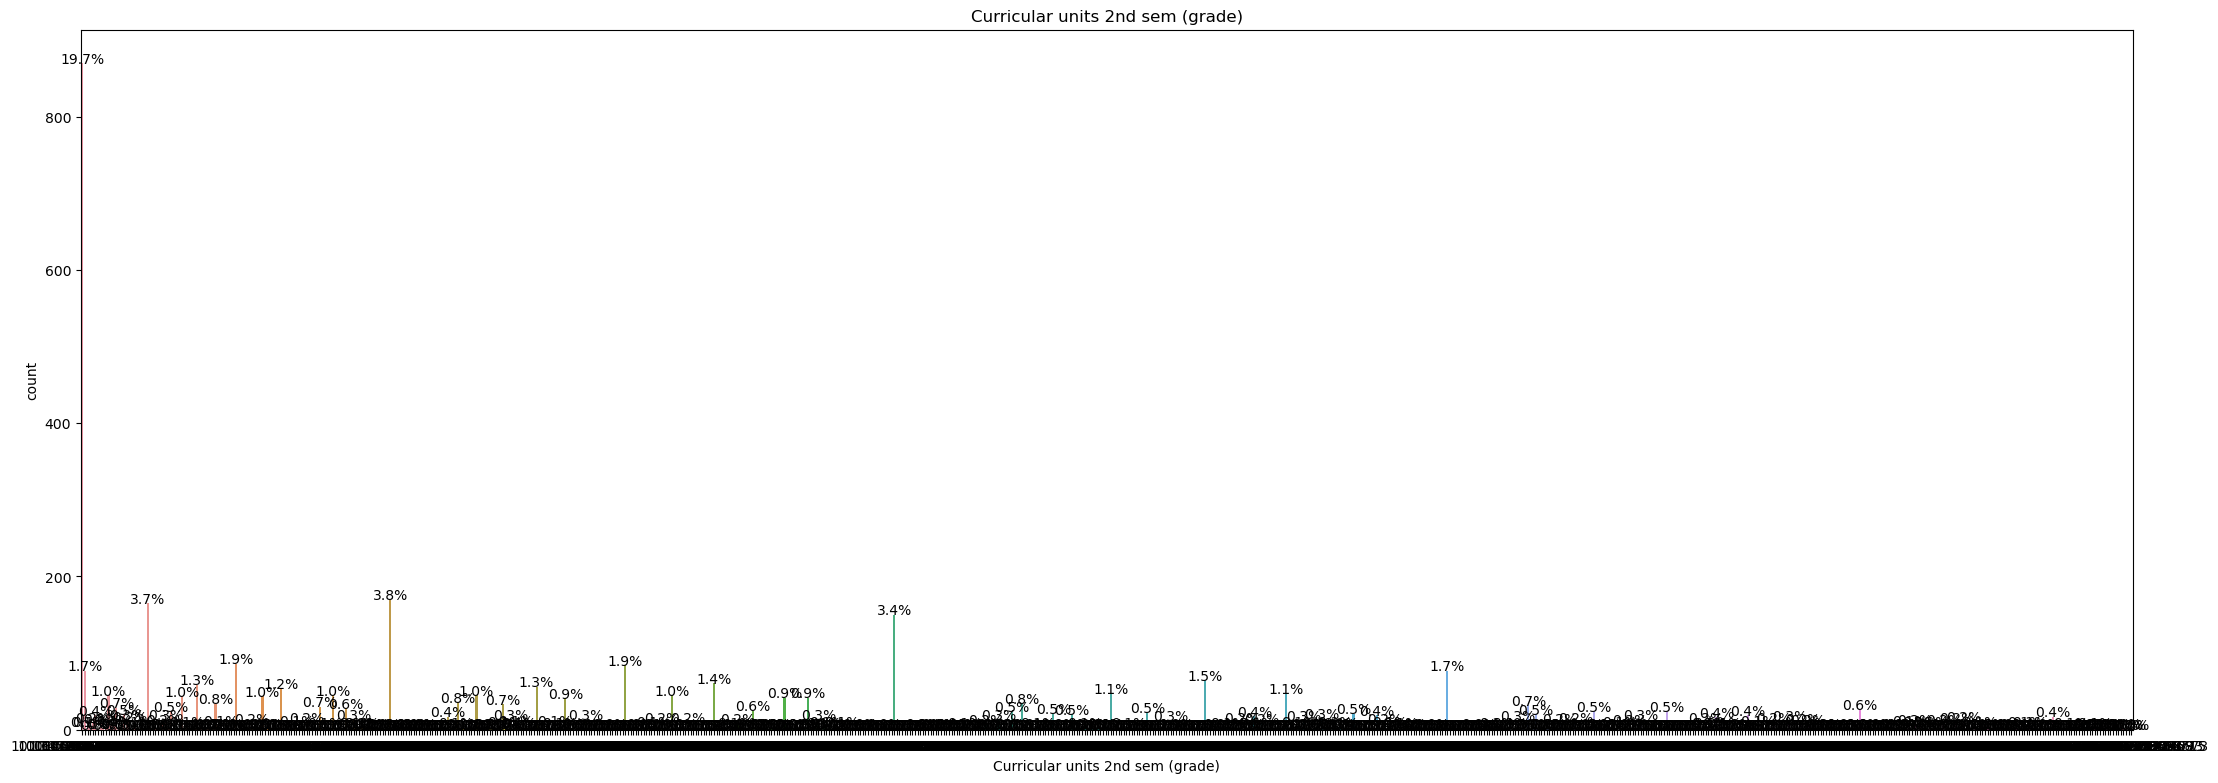

In [43]:
# Define the figure size

plt.figure(figsize=(90,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (grade)") 
plt.title("Curricular units 2nd sem (grade)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

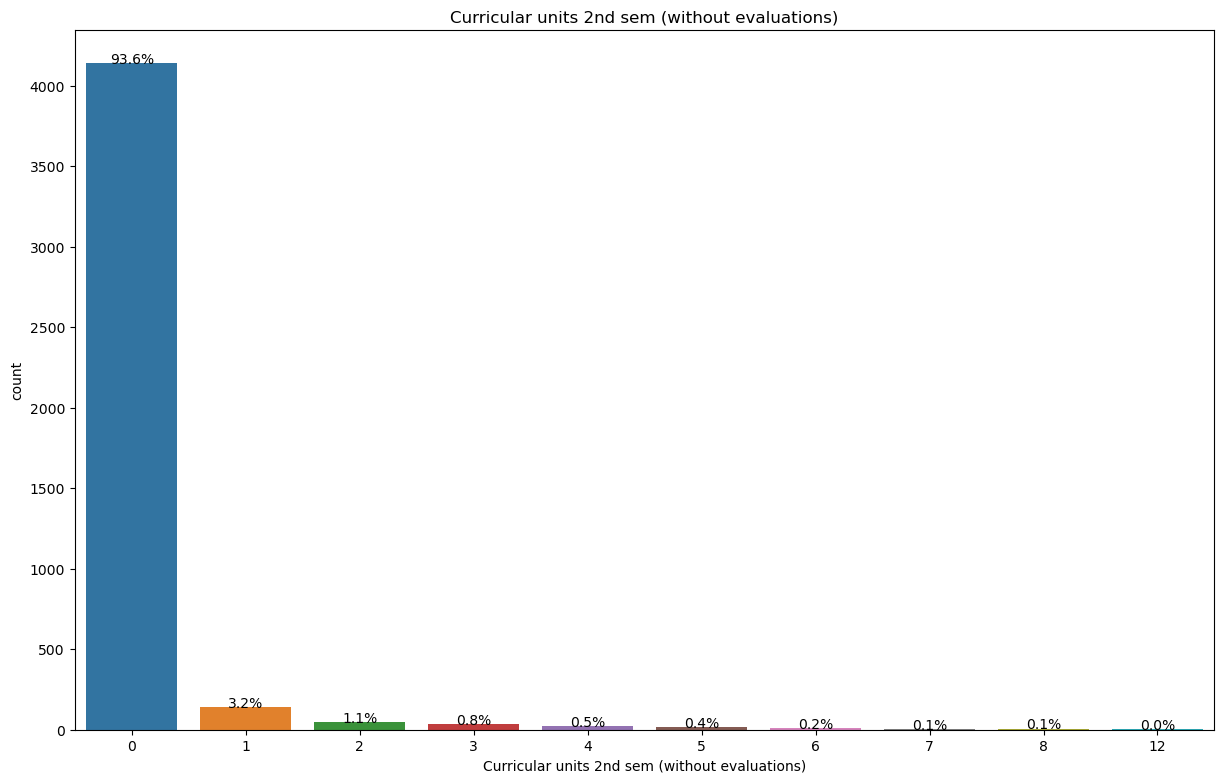

In [44]:
# Define the figure size

plt.figure(figsize=(50,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Curricular units 2nd sem (without evaluations)") 
plt.title("Curricular units 2nd sem (without evaluations)") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

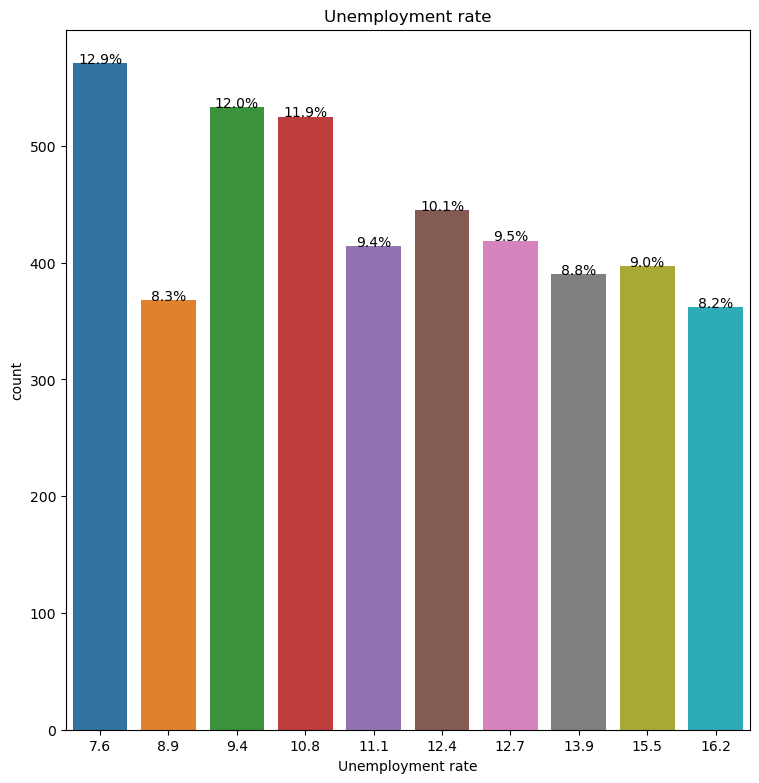

In [45]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Unemployment rate") 
plt.title("Unemployment rate") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

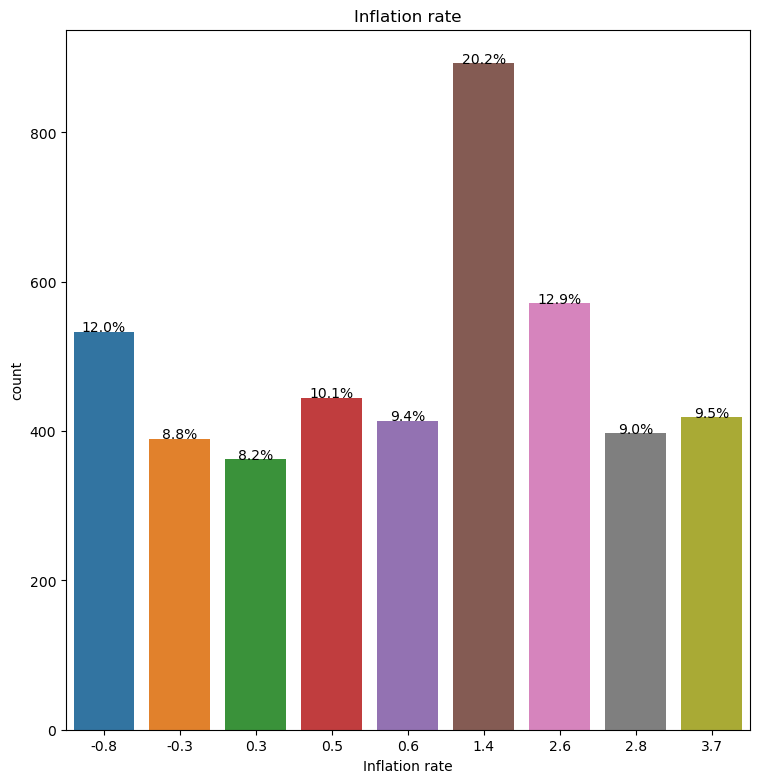

In [46]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="Inflation rate") 
plt.title("Inflation rate") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

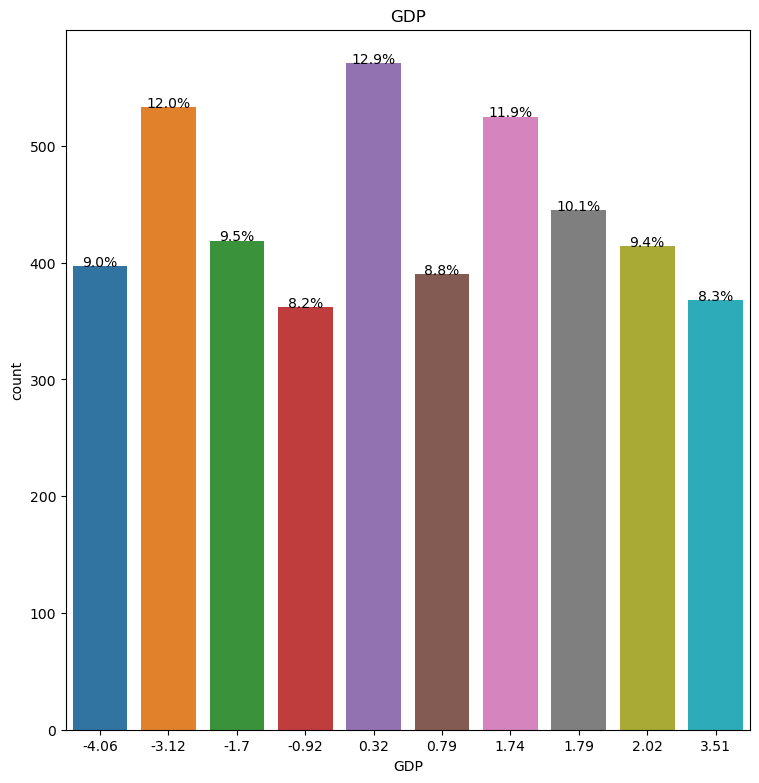

In [47]:
# Define the figure size

plt.figure(figsize=(30,20))

plt.subplot(231)
ax=sns.countplot(data=stdData, x="GDP") 
plt.title("GDP") 

# Calculate total number of data points
total_data_points = len(stdData)

# Add percentage labels to each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_data_points)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Show the plots
plt.show()

# Relation

In [48]:
stdData['Target'].unique()
stdData['Target'] = stdData['Target'].map({
    'Dropout':0,
    'Enrolled':1,
    'Graduate':2
})

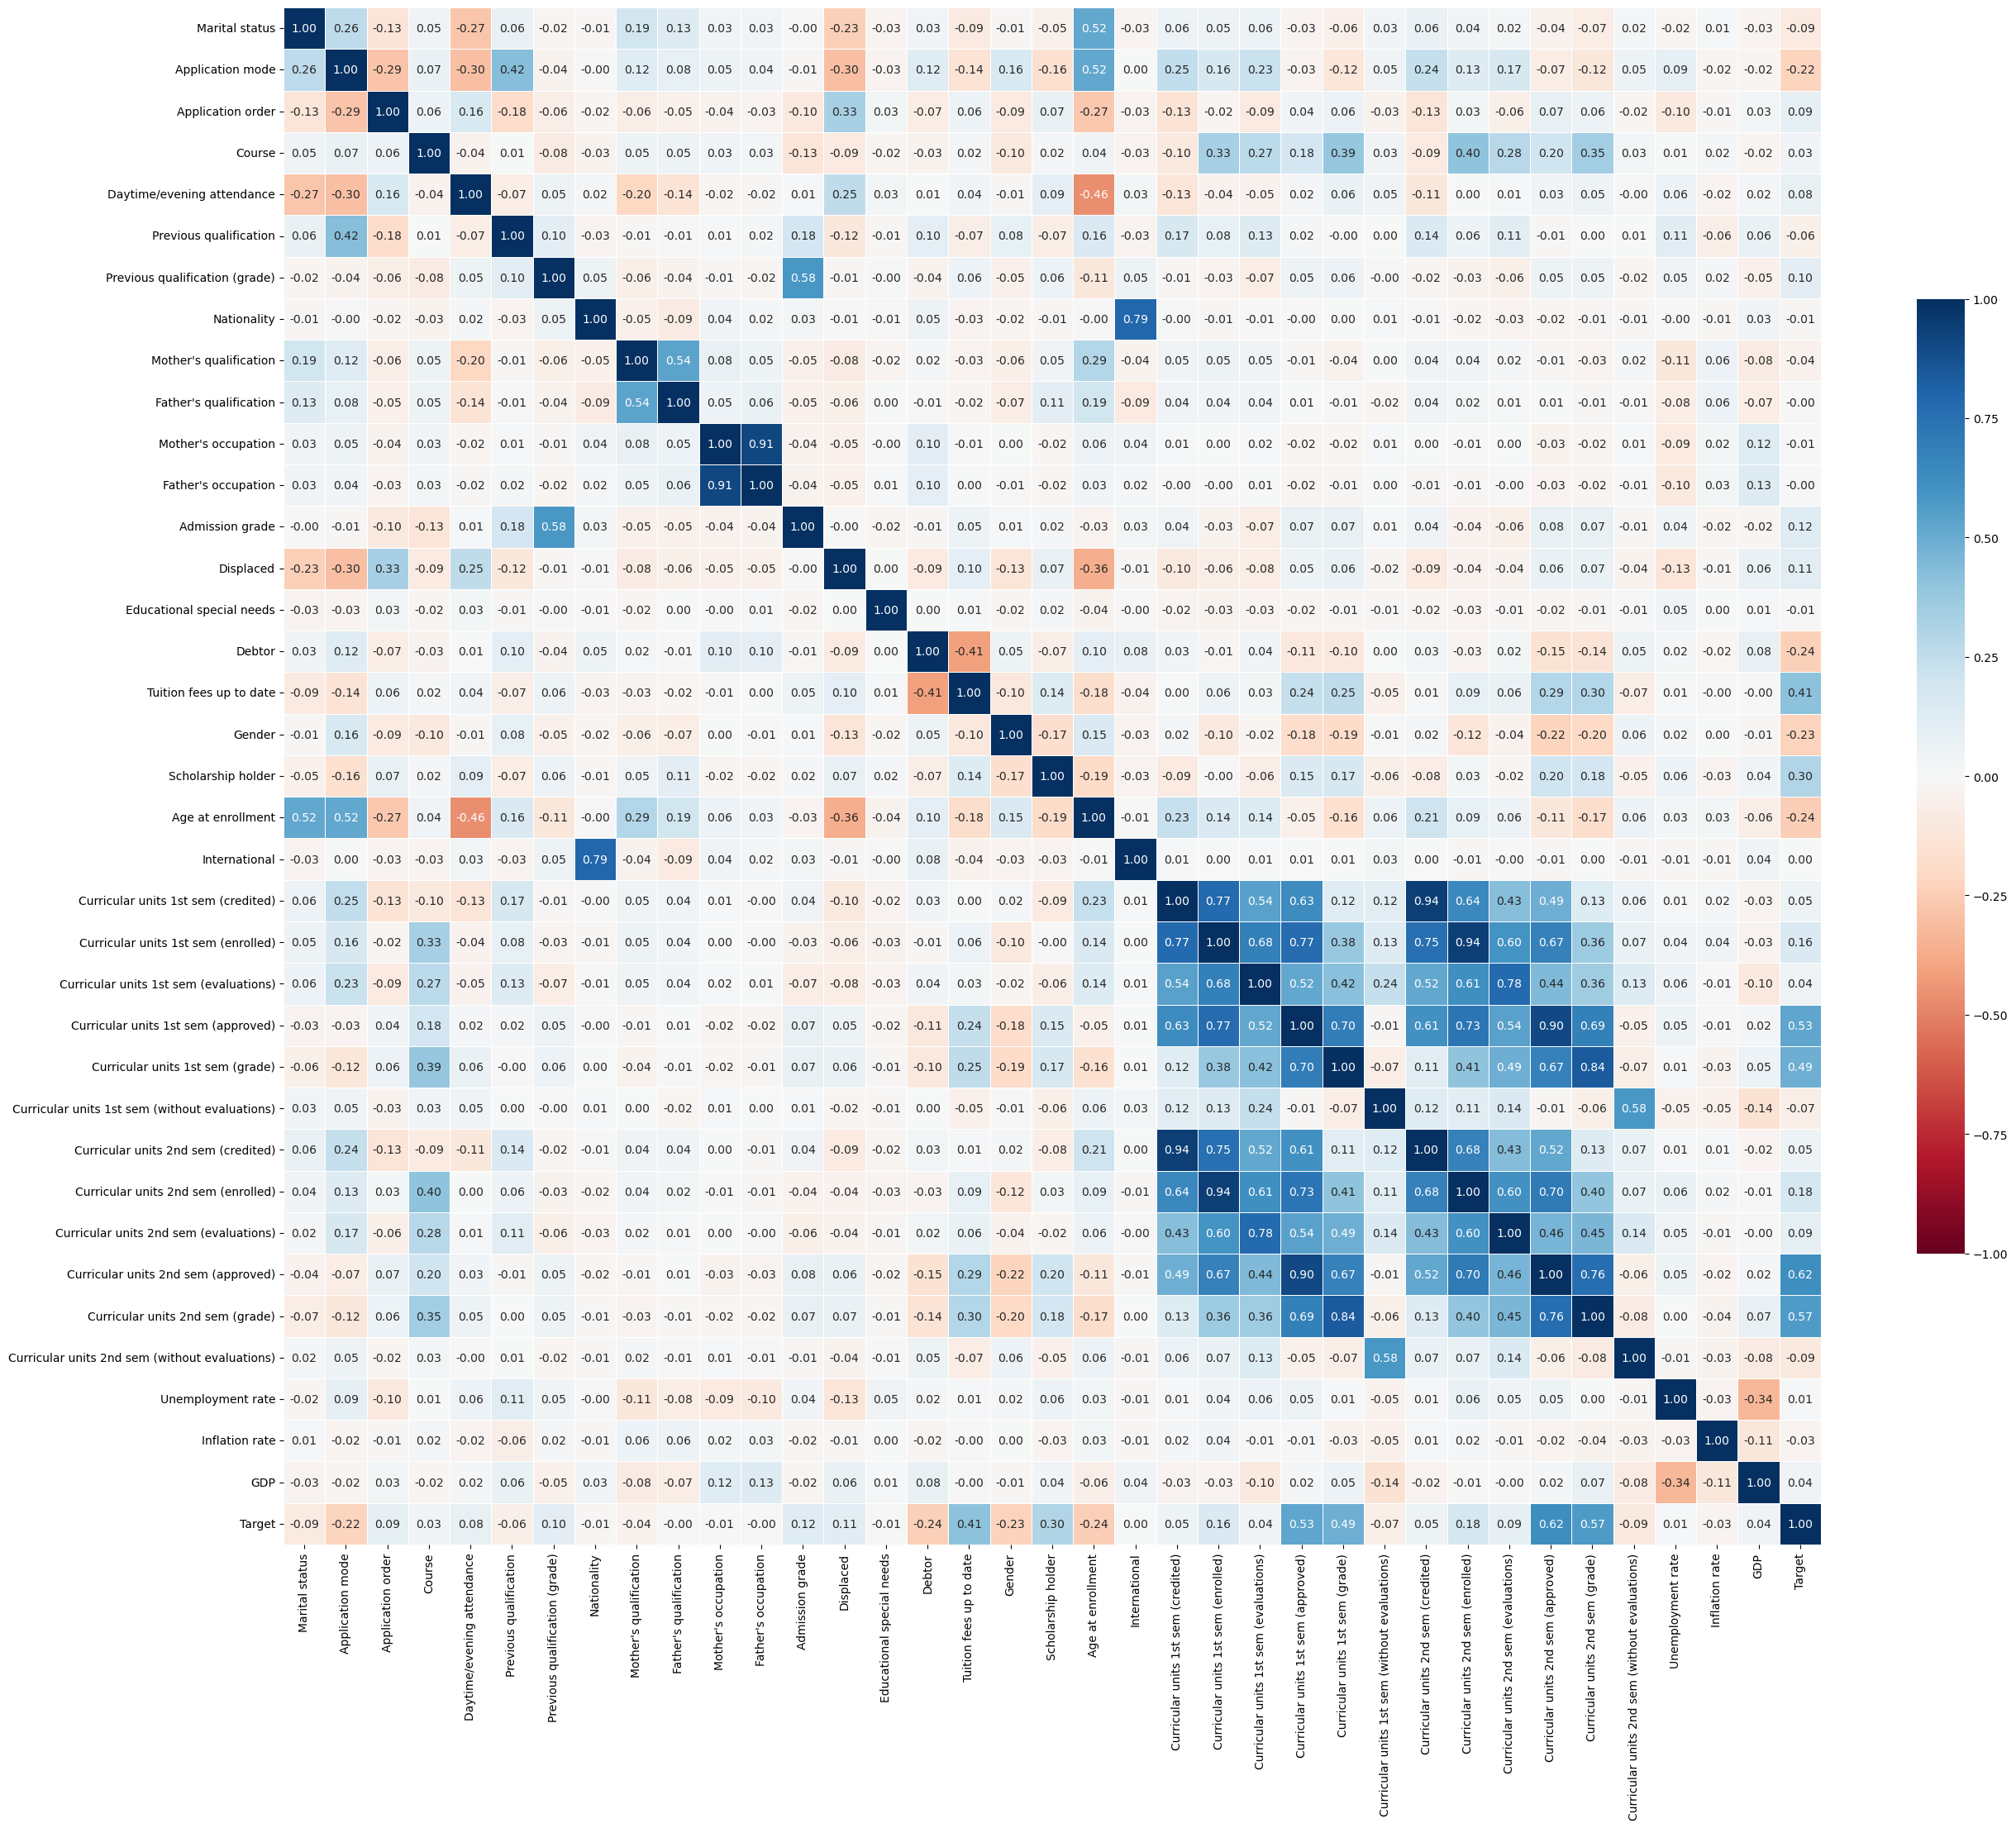

In [49]:
# Plotting a correlation matrix in heatmap
f = plt.figure(figsize=(30, 30))
sns.heatmap(stdData.corr(),annot=True, fmt=".2f",cmap='RdBu',vmax=1,vmin =-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show

plt.savefig("TaegetHeatmap.png")

In [50]:
stdData[stdData<0.19]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,-0.3,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,-0.8,-3.12,NaN
4,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,-0.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,-4.06,NaN
4420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
4421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,-0.3,NaN,0.0
4422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,-0.8,-3.12,NaN


In [51]:
stdData[stdData>0.8]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5.0,171,1.0,1,122.0,1,19,12,...,NaN,NaN,NaN,NaN,NaN,NaN,10.8,1.4,1.74,NaN
1,1,15,1.0,9254,1.0,1,160.0,1,1,3,...,NaN,6.0,6.0,6.0,13.666667,NaN,13.9,NaN,NaN,2.0
2,1,1,5.0,9070,1.0,1,122.0,1,37,37,...,NaN,6.0,NaN,NaN,NaN,NaN,10.8,1.4,1.74,NaN
3,1,17,2.0,9773,1.0,1,122.0,1,38,37,...,NaN,6.0,10.0,5.0,12.400000,NaN,9.4,NaN,NaN,2.0
4,2,39,1.0,8014,NaN,1,100.0,1,37,38,...,NaN,6.0,6.0,6.0,13.000000,NaN,13.9,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6.0,9773,1.0,1,125.0,1,1,1,...,NaN,6.0,8.0,5.0,12.666667,NaN,15.5,2.8,NaN,2.0
4420,1,1,2.0,9773,1.0,1,120.0,105,1,1,...,NaN,6.0,6.0,2.0,11.000000,NaN,11.1,NaN,2.02,NaN
4421,1,1,1.0,9500,1.0,1,154.0,1,37,37,...,NaN,8.0,9.0,1.0,13.500000,NaN,13.9,NaN,NaN,NaN
4422,1,1,1.0,9147,1.0,1,180.0,1,37,37,...,NaN,5.0,6.0,5.0,12.000000,NaN,9.4,NaN,NaN,2.0


# 3. Data preparation part

In [52]:
#Missing value
print("\nMissing Values:")
print(stdData.isnull().any().any())


Missing Values:
False


In [53]:
print(stdData.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nationality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [54]:
#Find duplicated data
print("Duplicated data:")
stdData.duplicated().sum()

Duplicated data:


0

In [55]:
stdData['Target'].unique()

array([0, 2, 1], dtype=int64)

In [56]:
stdData['Target'].value_counts()

2    2209
0    1421
1     794
Name: Target, dtype: int64

In [57]:
stdData

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,2
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,2


In [58]:
stdData.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,1.178119
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.888243
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,1.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,2.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,2.000000


In [59]:
stdData.corr()['Target']

Marital status                                   -0.089804
Application mode                                 -0.221747
Application order                                 0.089791
Course                                            0.034219
Daytime/evening attendance                        0.075107
Previous qualification                           -0.056039
Previous qualification (grade)                    0.103764
Nationality                                      -0.014801
Mother's qualification                           -0.043178
Father's qualification                           -0.001393
Mother's occupation                              -0.005629
Father's occupation                              -0.001899
Admission grade                                   0.120889
Displaced                                         0.113986
Educational special needs                        -0.007353
Debtor                                           -0.240999
Tuition fees up to date                           0.4098

In [60]:
#identify outlier 

# Calculating the Z-score for each data point
z_scores = np.abs(stats.zscore(stdData))

# Finding data points with a Z-score greater than 3
outliers = np.where(z_scores > 3)

# Printing the indices of the outliers
outliers


(array([   0,    5,    5, ..., 4420, 4422, 4423], dtype=int64),
 array([ 3, 19, 32, ..., 20,  6, 20], dtype=int64))

In [61]:
# Dropping the corresponding rows from the dataframe
out_df = stdData.drop(stdData.index[outliers[0]])

# Resetting the index of the dataframe
stdData = out_df.reset_index(drop=True)
stdData.shape
stdData

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
1,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
2,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
3,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
4,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3076,1,1,1,9070,1,1,124.0,1,37,19,...,1,6,9,5,12.500000,0,10.8,1.4,1.74,2
3077,1,43,1,9070,1,1,125.0,1,19,19,...,2,6,7,5,12.200000,0,13.9,-0.3,0.79,1
3078,1,1,1,9130,1,1,137.0,1,3,38,...,0,5,8,5,11.600000,0,9.4,-0.8,-3.12,2
3079,1,1,1,9070,1,1,132.0,1,1,1,...,0,6,6,6,13.500000,0,16.2,0.3,-0.92,2


In [62]:
attributes = stdData.columns
attributes

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

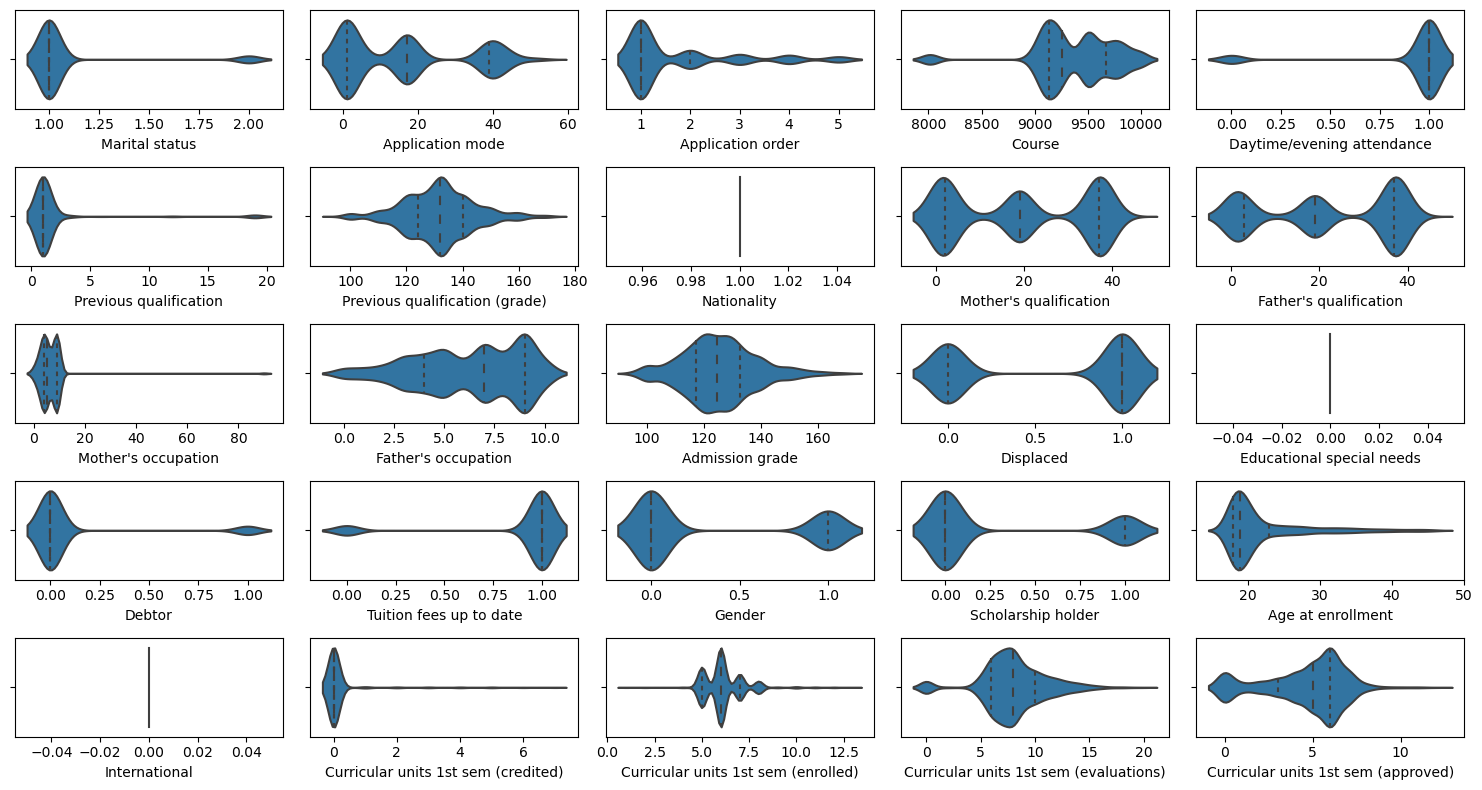

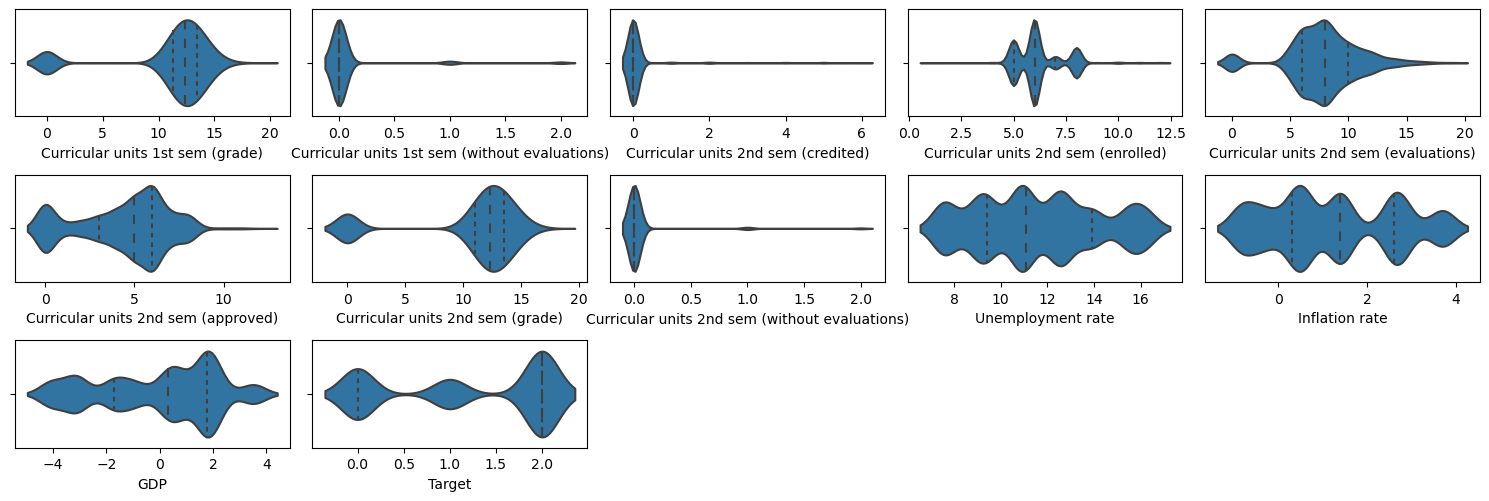

In [63]:
# Define the number of subplots per figure
subplots_per_figure = 25  # Adjust as needed



# Calculate the number of figures required
num_figures = (len(attributes) + subplots_per_figure - 1) // subplots_per_figure

for figure_num in range(num_figures):
    start_idx = figure_num * subplots_per_figure
    end_idx = min((figure_num + 1) * subplots_per_figure, len(attributes))
    
   
    
    # Create a new figure
    plt.figure(figsize=(15, 8))
    
    # Create subplots for the current set of attributes
    for i, attribute in enumerate(attributes[start_idx:end_idx]):
        plt.subplot(5, 5, i + 1)  # Adjust the grid size as needed
        sns.violinplot(x=stdData[attribute], inner="quart")
    
    plt.tight_layout()
    plt.show()

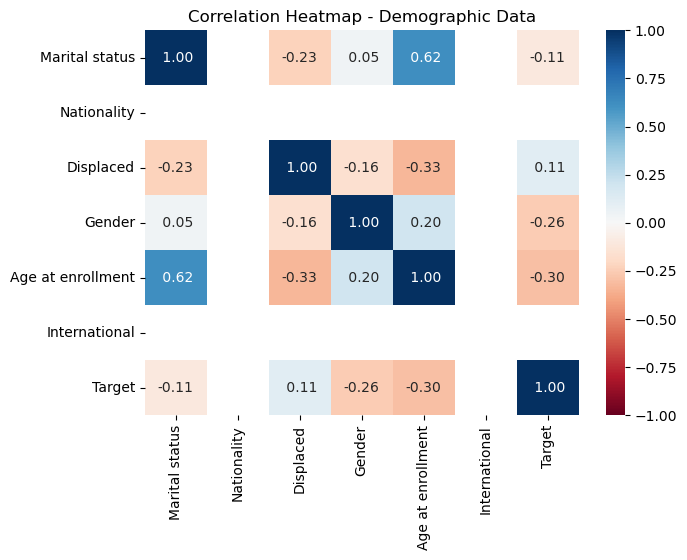

In [64]:
#As we have too many features, so we decide to seperate all features to 4 set 

# Demographic data

demographic_data = stdData[["Marital status", "Nationality", "Displaced", "Gender", 
                "Age at enrollment", "International", "Target"]]

# Socio-economic data
soceco_data = stdData[["Mother's qualification", "Father's qualification", 
              "Mother's occupation", "Father's occupation", 
              "Educational special needs", "Debtor", "Tuition fees up to date", "Scholarship holder", "Target"]]

# Macro-economic Enrollment Data
meco_data = stdData[['Unemployment rate', 'Inflation rate', 'GDP', 'Application mode', 
              'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Target']]

# Academic data
academic_data = stdData[['Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Target']]
# Correlation Matric for Demographic data

plt.figure(figsize=(7,5))
sns.heatmap(demographic_data.corr(), annot=True, cmap='RdBu',vmax=1,vmin =-1, center=0, fmt=' .2f')
plt.title('Correlation Heatmap - Demographic Data')
plt.show()

In [65]:
#We decide to drop features of nasionality and international
#drop features
features_needto_drop = []
demographic_features_drop = ['Nationality','International']
features_needto_drop.extend(demographic_features_drop)


In [66]:
features_needto_drop

['Nationality', 'International']

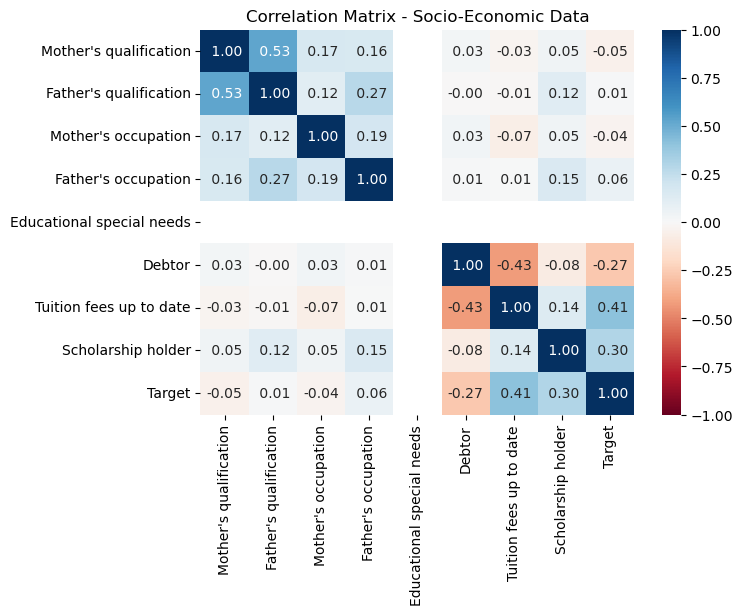

In [67]:
# Correlation Matrix for socio-economic data
plt.figure(figsize=(7,5))
sns.heatmap(soceco_data.corr(), annot=True,cmap='RdBu',vmax=1,vmin =-1, center=0, fmt=' .2f')
plt.title('Correlation Matrix - Socio-Economic Data')
plt.show()

In [68]:
#combine attributes
# Combine 'Mother Qualification' and 'Father Qualification' into a single 'Parents' Qualification' column
#Because both of them have same attribute as each other and correlation of them also can consider as high
stdData["Parents\'s Qualification"] = stdData["Mother's qualification"]  + stdData["Father's qualification"]

#After combine we will need to add parents qualification inside the soceco_data 
#mother's qualification and father qualification can be drop
soceco_data["Parents\'s Qualification"] = stdData["Parents\'s Qualification"]

In [69]:
#check whether is that successful combine 
stdData

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Parents's Qualification
0,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,2,4
1,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,0,74
2,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,2,75
3,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,2,75
4,1,1,1,9500,1,1,142.0,1,19,38,...,8,8,8,14.345000,0,15.5,2.8,-4.06,2,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3076,1,1,1,9070,1,1,124.0,1,37,19,...,6,9,5,12.500000,0,10.8,1.4,1.74,2,56
3077,1,43,1,9070,1,1,125.0,1,19,19,...,6,7,5,12.200000,0,13.9,-0.3,0.79,1,38
3078,1,1,1,9130,1,1,137.0,1,3,38,...,5,8,5,11.600000,0,9.4,-0.8,-3.12,2,41
3079,1,1,1,9070,1,1,132.0,1,1,1,...,6,6,6,13.500000,0,16.2,0.3,-0.92,2,2


In [70]:
#Adding the features that want to drop in the previous drop set 
soceco_features_drop=['Tuition fees up to date','Educational special needs','Mother\'s qualification', 'Father\'s qualification'
                      ,'Mother\'s occupation', 'Father\'s occupation']
features_needto_drop.extend(soceco_features_drop)


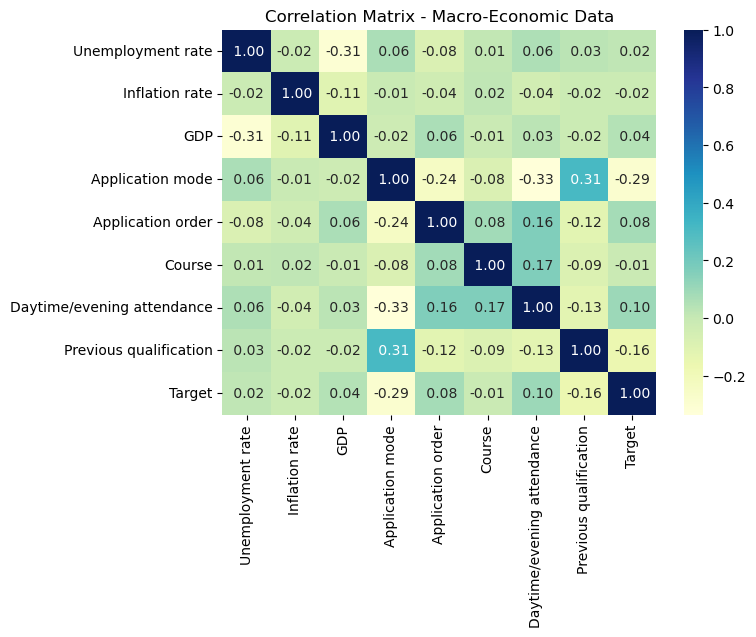

In [71]:
# Correlation Matrix for Macro-Economic Data
plt.figure(figsize=(7,5))
sns.heatmap(meco_data.corr(), annot=True, cmap='YlGnBu', fmt=' .2f')
plt.title('Correlation Matrix - Macro-Economic Data')
plt.show()

In [72]:
#Adding the features that want to drop in the previous drop set 
meco_features_drop=['Previous qualification']
features_needto_drop.extend(meco_features_drop)

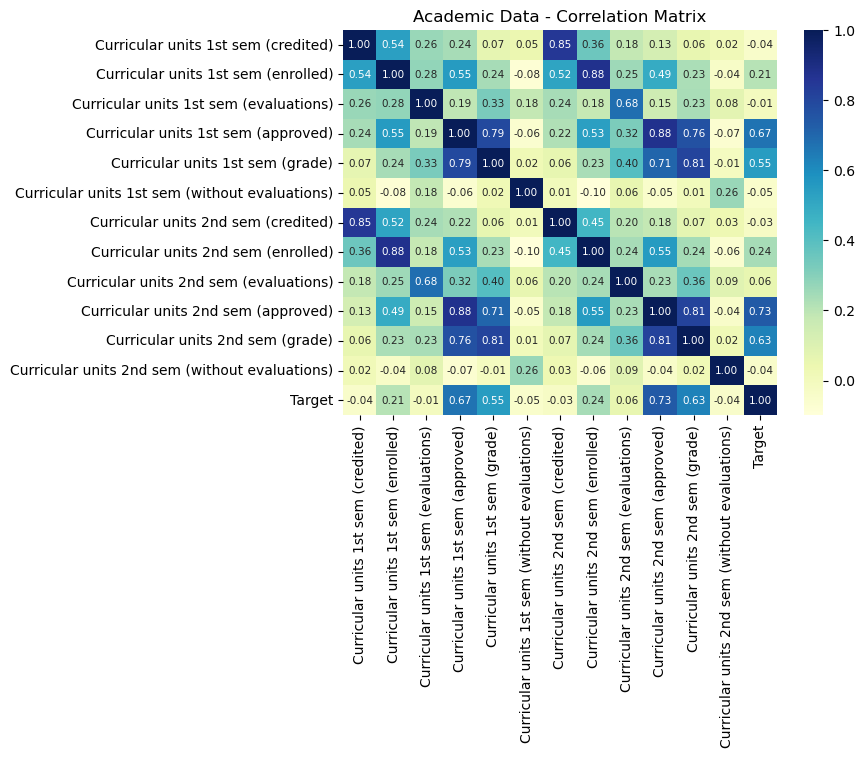

In [73]:
# Correlation Matrix for Academic Data
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(academic_data.corr(), annot=True, cmap="YlGnBu", fmt='.2f', annot_kws={"size": 7.5})
plt.title("Academic Data - Correlation Matrix")
plt.show()

In [74]:
academic_features_drop = ['Curricular units 1st sem (credited)', 
                           'Curricular units 1st sem (enrolled)',
                           'Curricular units 1st sem (evaluations)', 
                           'Curricular units 1st sem (approved)',
                           'Curricular units 1st sem (grade)', 
                           'Curricular units 1st sem (without evaluations)',
                           'Curricular units 2nd sem (credited)',
                           'Curricular units 2nd sem (without evaluations)']
features_needto_drop.extend(academic_features_drop)


In [75]:
features_needto_drop

['Nationality',
 'International',
 'Tuition fees up to date',
 'Educational special needs',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Previous qualification',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (without evaluations)']

In [76]:
stdData.drop(features_needto_drop, axis=1, inplace=True)
stdData.head(3)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification (grade),Admission grade,Displaced,Debtor,Gender,...,Age at enrollment,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target,Parents's Qualification
0,1,15,1,9254,1,160.0,142.5,1,0,1,...,19,6,6,6,13.666667,13.9,-0.3,0.79,2,4
1,1,1,5,9070,1,122.0,124.8,1,0,1,...,19,6,0,0,0.000000,10.8,1.4,1.74,0,74
2,1,17,2,9773,1,122.0,119.6,1,0,0,...,20,6,10,5,12.400000,9.4,-0.8,-3.12,2,75


In [77]:
#show currently attributes
stdData.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification (grade)',
       'Admission grade', 'Displaced', 'Debtor', 'Gender',
       'Scholarship holder', 'Age at enrollment',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target', 'Parents's Qualification'],
      dtype='object')

# Heatmap after drop attributes

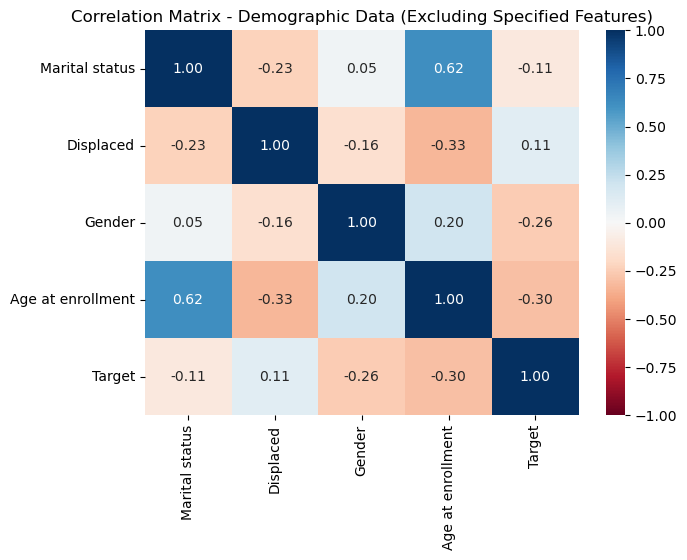

In [78]:
# Correlation Matric for Demographic data

# Create a DataFrame with only the selected features
selected_data = demographic_data.drop(demographic_features_drop, axis=1)

# Define the figure size for the heatmap
plt.figure(figsize=(7, 5))

# Create the correlation matrix for the selected data and plot the heatmap
sns.heatmap(selected_data.corr(), annot=True, cmap='RdBu', vmax=1, vmin=-1, center=0, fmt='.2f')

# Set the title for the heatmap
plt.title('Correlation Matrix - Demographic Data (Excluding Specified Features)')

# Show the heatmap
plt.show()

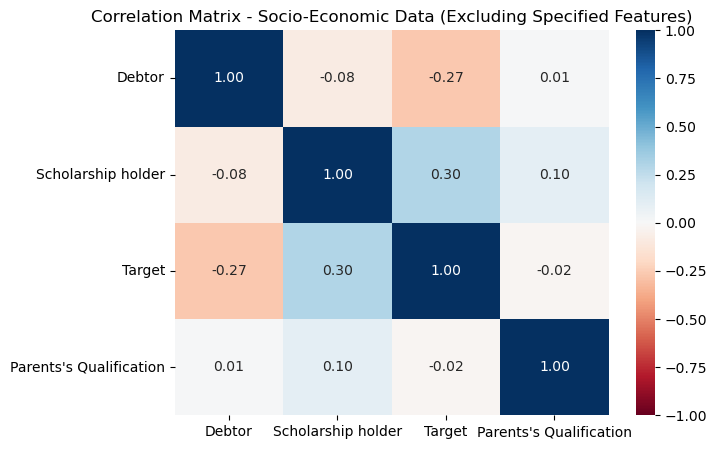

In [79]:
# Create a DataFrame with only the selected features
selected_data2 = soceco_data.drop(soceco_features_drop, axis=1)

# Define the figure size for the heatmap
plt.figure(figsize=(7, 5))

# Create the correlation matrix for the selected data and plot the heatmap
sns.heatmap(selected_data2.corr(), annot=True, cmap='RdBu', vmax=1, vmin=-1, center=0, fmt='.2f')

# Set the title for the heatmap
plt.title('Correlation Matrix - Socio-Economic Data (Excluding Specified Features)')

# Show the heatmap
plt.show()

<Figure size 700x500 with 0 Axes>

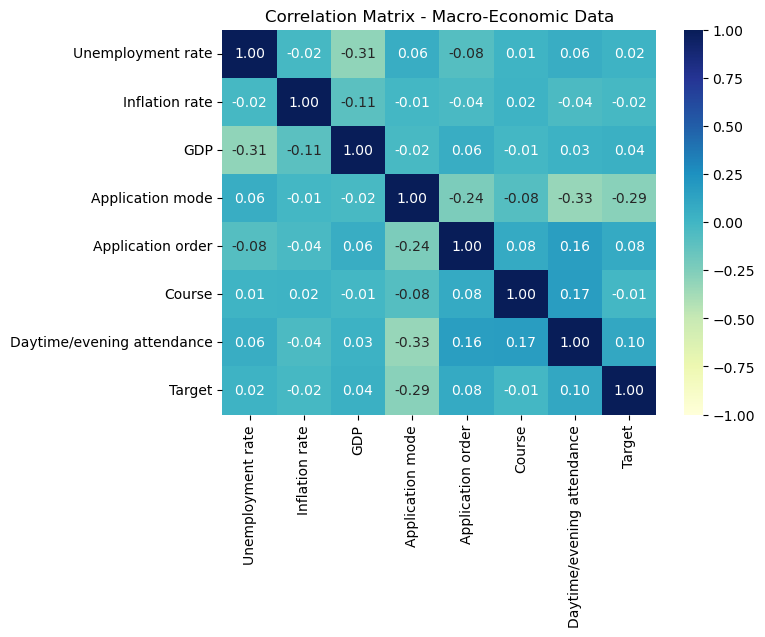

In [80]:
# Correlation Matrix for Macro-Economic Data
plt.figure(figsize=(7,5))

# Create a DataFrame with only the selected features
selected_data3 = meco_data.drop(meco_features_drop, axis=1)

# Define the figure size for the heatmap
plt.figure(figsize=(7, 5))

# Create the correlation matrix for the selected data and plot the heatmap
sns.heatmap(selected_data3.corr(), annot=True, cmap='YlGnBu', vmax=1, vmin=-1, center=0, fmt='.2f')



# Show the heatmap
plt.title('Correlation Matrix - Macro-Economic Data')
plt.show()

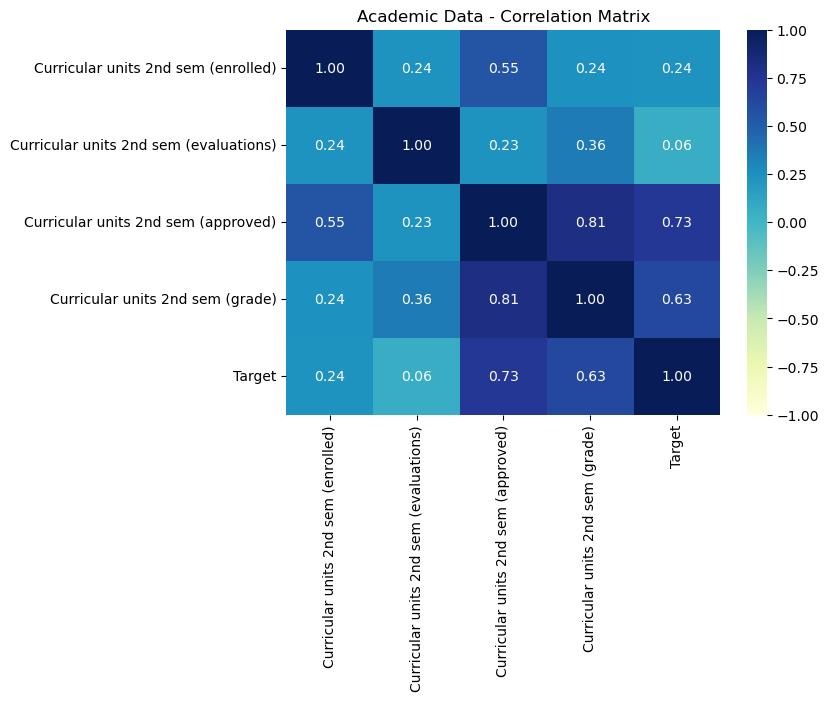

In [81]:
# Correlation Matrix for Academic Data
fig, ax = plt.subplots(figsize=(7,5))

# Create a DataFrame with only the selected features
selected_data3 = academic_data.drop(academic_features_drop, axis=1)

# Create the correlation matrix for the selected data and plot the heatmap
sns.heatmap(selected_data3.corr(), annot=True, cmap='YlGnBu', vmax=1, vmin=-1, center=0, fmt='.2f')

plt.title("Academic Data - Correlation Matrix")
plt.show()

# Remove Enrolled in Target

In [82]:
stdData['Target'].value_counts()

2    1591
0     944
1     546
Name: Target, dtype: int64

In [83]:
stdData['Target'].unique()
stdData['Target'] = stdData['Target'].map({
    0:'Dropout',
    1:'Enrolled',
    2:'Graduate'
})

In [84]:
stdData['Target'].unique()

array(['Graduate', 'Dropout', 'Enrolled'], dtype=object)

In [85]:
# Remove all rows in the datafram where the value in the Target column equals Enrolled
stdData = stdData[stdData.Target != 'Enrolled']

In [86]:
stdData['Target'].unique()

array(['Graduate', 'Dropout'], dtype=object)

In [87]:
encoder = LabelEncoder()
stdData['Target'] = encoder.fit_transform(stdData['Target'])
stdData.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification (grade),Admission grade,Displaced,Debtor,Gender,...,Age at enrollment,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target,Parents's Qualification
0,1,15,1,9254,1,160.0,142.5,1,0,1,...,19,6,6,6,13.666667,13.9,-0.3,0.79,1,4
1,1,1,5,9070,1,122.0,124.8,1,0,1,...,19,6,0,0,0.000000,10.8,1.4,1.74,0,74
2,1,17,2,9773,1,122.0,119.6,1,0,0,...,20,6,10,5,12.400000,9.4,-0.8,-3.12,1,75
3,2,39,1,8014,0,100.0,141.5,0,0,0,...,45,6,6,6,13.000000,13.9,-0.3,0.79,1,75
4,1,1,1,9500,1,142.0,128.4,1,0,0,...,18,8,8,8,14.345000,15.5,2.8,-4.06,1,57


# Train Test Split

In [88]:
X = stdData.drop('Target', axis=1)
y = stdData['Target']

In [89]:
#80% - 20%
X_train, X_test, y_train, y_test = train_test_split(stdData.drop('Target',axis=1), stdData['Target'], test_size=0.2, random_state=101)

In [90]:
X

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification (grade),Admission grade,Displaced,Debtor,Gender,Scholarship holder,Age at enrollment,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Parents's Qualification
0,1,15,1,9254,1,160.0,142.5,1,0,1,0,19,6,6,6,13.666667,13.9,-0.3,0.79,4
1,1,1,5,9070,1,122.0,124.8,1,0,1,0,19,6,0,0,0.000000,10.8,1.4,1.74,74
2,1,17,2,9773,1,122.0,119.6,1,0,0,0,20,6,10,5,12.400000,9.4,-0.8,-3.12,75
3,2,39,1,8014,0,100.0,141.5,0,0,0,0,45,6,6,6,13.000000,13.9,-0.3,0.79,75
4,1,1,1,9500,1,142.0,128.4,1,0,0,1,18,8,8,8,14.345000,15.5,2.8,-4.06,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3075,2,43,1,9991,0,140.0,122.7,0,0,1,0,38,5,6,5,14.333333,13.9,-0.3,0.79,74
3076,1,1,1,9070,1,124.0,121.2,0,0,1,1,20,6,9,5,12.500000,10.8,1.4,1.74,56
3078,1,1,1,9130,1,137.0,129.3,1,0,0,0,18,5,8,5,11.600000,9.4,-0.8,-3.12,41
3079,1,1,1,9070,1,132.0,133.8,1,0,0,1,20,6,6,6,13.500000,16.2,0.3,-0.92,2


In [91]:
y.value_counts()

1    1591
0     944
Name: Target, dtype: int64

In [92]:
#choose either oversampling or undersampling
#in this case we use oversampling
# Separate features (X) and target variable (y)
from imblearn.over_sampling import SMOTE

X = stdData.drop("Target", axis=1)  # Adjust "target_variable" to your target variable's name
y = stdData["Target"]

smote = SMOTE(sampling_strategy='auto', random_state=42)  # You can adjust sampling_strategy if needed
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()

1    1591
0    1591
Name: Target, dtype: int64

# Normalisation

In [93]:
features = stdData.columns.drop('Target')
features

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification (grade)',
       'Admission grade', 'Displaced', 'Debtor', 'Gender',
       'Scholarship holder', 'Age at enrollment',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Parents's Qualification'],
      dtype='object')

# Min-max Normalise

In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
stdData[features] = scaler.fit_transform(stdData[features])

In [95]:
# Normalize X
x_scaler = MinMaxScaler()
X_normalized = x_scaler.fit_transform(X)

y = stdData['Target'].to_numpy()  # Convert 'target' to a NumPy array

y_scaler = MinMaxScaler()
y_normalized = y_scaler.fit_transform(y.reshape(-1, 1)) 

In [96]:
stdData.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification (grade),Admission grade,Displaced,Debtor,Gender,...,Age at enrollment,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target,Parents's Qualification
0,0.0,0.28,0.00,0.627213,1.0,0.844156,0.633333,1.0,0.0,1.0,...,0.068966,0.454545,0.315789,0.500000,0.772464,0.732558,0.111111,0.640687,1,0.024390
1,0.0,0.00,1.00,0.534143,1.0,0.350649,0.397333,1.0,0.0,1.0,...,0.068966,0.454545,0.000000,0.000000,0.000000,0.372093,0.488889,0.766182,0,0.878049
2,0.0,0.32,0.25,0.889732,1.0,0.350649,0.328000,1.0,0.0,0.0,...,0.103448,0.454545,0.526316,0.416667,0.700870,0.209302,0.000000,0.124174,1,0.890244
3,1.0,0.76,0.00,0.000000,0.0,0.064935,0.620000,0.0,0.0,0.0,...,0.965517,0.454545,0.315789,0.500000,0.734783,0.732558,0.111111,0.640687,1,0.890244
4,0.0,0.00,0.00,0.751644,1.0,0.610390,0.445333,1.0,0.0,0.0,...,0.034483,0.636364,0.421053,0.666667,0.810804,0.918605,0.800000,0.000000,1,0.670732


# Logistic Regression

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [98]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

In [99]:
logmodel = LogisticRegression(max_iter=10000)

In [100]:
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

In [101]:
predictions = logmodel.predict(X_test)

In [102]:
# Calculate accuracy
log_accuracy = accuracy_score(y_test, predictions)

# Calculate the F1-score
log_f1 = f1_score(y_test, predictions)

# Calculate precision
log_precision = precision_score(y_test, predictions)

# Calculate recall
log_recall = recall_score(y_test, predictions)


print("LOGISTICT REGRESSION:\n")
print("Accuracy: {:.2f}".format(log_accuracy))
print("F1-score:{:.2f}".format(log_f1))
print("Precision: {:.2f}".format(log_precision))
print("Recall: {:.2f}".format(log_recall))
print("\n")
print(classification_report(y_test,predictions))
print("\n")
print(confusion_matrix(y_test,predictions))


LOGISTICT REGRESSION:

Accuracy: 0.93
F1-score:0.95
Precision: 0.93
Recall: 0.97


              precision    recall  f1-score   support

           0       0.94      0.87      0.90       185
           1       0.93      0.97      0.95       322

    accuracy                           0.93       507
   macro avg       0.93      0.92      0.92       507
weighted avg       0.93      0.93      0.93       507



[[161  24]
 [ 11 311]]


In [103]:
log_params = {
    'C': [0.01, 1, 10],
    'penalty': ['11', '12', 'elasticnet', 'none'],
    'solver': ['liblinear', 'newton-cg', 'saga']
}
# Perform grid search
grid_search = GridSearchCV( LogisticRegression(max_iter=10000), log_params, cv=5)
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best  hyperparameters:",grid_search.best_estimator_)
print("Best score {:.2f}".format(grid_search.best_score_))


Best  hyperparameters: LogisticRegression(C=0.01, max_iter=10000, penalty='none', solver='newton-cg')
Best score 0.91


# K-Nearst Neighbor

In [104]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

In [105]:
knn = KNeighborsClassifier(n_neighbors=1)

In [106]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [107]:
predictions = knn.predict(X_test)

In [108]:
# Calculate accuracy
knn_accuracy = accuracy_score(y_test, predictions)

# Calculate the F1-score
knn_f1 = f1_score(y_test, predictions)

# Calculate precision
knn_precision = precision_score(y_test, predictions)

# Calculate recall
knn_recall = recall_score(y_test, predictions)

# Calculate RMSE
knn_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("K-Nearst Neighbor:\n")
print("Accuracy: {:.2f}".format(knn_accuracy))
print("F1-score:{:.2f}".format(knn_f1))
print("Precision: {:.2f}".format(knn_precision))
print("Recall: {:.2f}".format(knn_recall))

print(f"Root Mean Square Error (RMSE): {knn_rmse:.2f}")

print("\n")
print(classification_report(y_test,predictions))
print("\n")
print(confusion_matrix(y_test,predictions))

K-Nearst Neighbor:

Accuracy: 0.77
F1-score:0.82
Precision: 0.79
Recall: 0.86
Root Mean Square Error (RMSE): 0.48


              precision    recall  f1-score   support

           0       0.71      0.61      0.66       185
           1       0.79      0.86      0.82       322

    accuracy                           0.77       507
   macro avg       0.75      0.73      0.74       507
weighted avg       0.76      0.77      0.76       507



[[113  72]
 [ 46 276]]


In [109]:
param_grid = {
    'n_neighbors' : [1,2,3,4,8,9,14,19,20,25],
    'weights' : ['uniform','distance'],
    'algorithm' : ['auto','ball_tree','kd_tree','brute']
}

# Perform grid search
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best hyperparameters:",grid_search.best_estimator_)
print("Best score :{:.2f}".format(grid_search.best_score_))


Best hyperparameters: KNeighborsClassifier(n_neighbors=8, weights='distance')
Best score :0.76


# Support Vector Machine

In [110]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

In [111]:
# Set the class weights as we needed
class_weights = {0: 1.0, 1: 1.0}

# Create the SVC model with adjusted class weights
model = SVC(class_weight=class_weights)


In [112]:
model.fit(X_train,y_train)

SVC(class_weight={0: 1.0, 1: 1.0})

In [113]:
predictions = model.predict(X_test)

In [114]:
# Calculate accuracy
svm_accuracy = accuracy_score(y_test, predictions)

# Calculate the F1-score
svm_f1 = f1_score(y_test, predictions)

# Calculate precision
svm_precision = precision_score(y_test, predictions)

# Calculate recall
svm_recall = recall_score(y_test, predictions)

print("Support Vector Machine:\n")
print("Accuracy: {:.2f}".format(svm_accuracy))
print("F1-score:{:.2f}".format(svm_f1))
print("Precision: {:.2f}".format(svm_precision))
print("Recall: {:.2f}".format(svm_recall))

print("\n")
print(classification_report(y_test,predictions))
print("\n")
print(confusion_matrix(y_test,predictions))

Support Vector Machine:

Accuracy: 0.64
F1-score:0.78
Precision: 0.64
Recall: 1.00


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       185
           1       0.64      1.00      0.78       322

    accuracy                           0.64       507
   macro avg       0.32      0.50      0.39       507
weighted avg       0.40      0.64      0.49       507



[[  0 185]
 [  0 322]]


# Randomised Search to find best hyperparameters

In [115]:
#Apply Randomised Search to find best hyperparameters
svm_param = {
    'C': [0.1, 1, 10, 100, 300],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
}

In [116]:
svm = SVC(class_weight=class_weights)

random_search = RandomizedSearchCV(
    svm, param_distributions=svm_param, n_iter=10, cv=5, scoring='accuracy', random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(class_weight={0: 1.0, 1: 1.0}),
                   param_distributions={'C': [0.1, 1, 10, 100, 300],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   random_state=42, scoring='accuracy')

In [117]:
best_model = random_search.best_estimator_
print("Best  hyperparameters:" ,best_model)
print("Best score: {:.2f}".format(random_search.best_score_))

Best  hyperparameters: SVC(C=10, class_weight={0: 1.0, 1: 1.0}, kernel='linear')
Best score: 0.91


# C parameter

In [118]:
clf = SVC(kernel='linear', C=10).fit(X_train, y_train)

print('Accuracy of Linear  SVC classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Linear  SVC classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))


#size c parameter more highest will get more accurate data and it is not limit until occur optimatic value


Accuracy of Linear  SVC classifier on training set: 0.91
Accuracy of Linear  SVC classifier on test set: 0.93


# Decision Tree

In [119]:
from sklearn.tree import DecisionTreeClassifier

In [120]:
dtree = DecisionTreeClassifier()

In [121]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [122]:
predictions = dtree.predict(X_test)


In [123]:
# Calculate accuracy
dct_accuracy = accuracy_score(y_test, predictions)

# Calculate the F1-score
dct_f1 = f1_score(y_test, predictions)

# Calculate precision
dct_precision = precision_score(y_test, predictions)

# Calculate recall
dct_recall = recall_score(y_test, predictions)

print("Decision Tree:\n")
print("Accuracy: {:.2f}".format(dct_accuracy))
print("F1-score:{:.2f}".format(dct_f1))
print("Precision: {:.2f}".format(dct_precision))
print("Recall: {:.2f}".format(dct_recall))
print("\n")
print(classification_report(y_test,predictions))
print("\n")
print(confusion_matrix(y_test,predictions))

Decision Tree:

Accuracy: 0.86
F1-score:0.89
Precision: 0.89
Recall: 0.90


              precision    recall  f1-score   support

           0       0.82      0.81      0.81       185
           1       0.89      0.90      0.89       322

    accuracy                           0.86       507
   macro avg       0.85      0.85      0.85       507
weighted avg       0.86      0.86      0.86       507



[[149  36]
 [ 33 289]]


In [124]:
dtc_params = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_leaf': [5, 10, 20, 30],
}

# Perform grid search
grid_search = GridSearchCV(DecisionTreeClassifier(), dtc_params, cv=5)
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best  hyperparameters:",grid_search.best_estimator_)
print("Best score :{:.2f}".format(grid_search.best_score_))


Best  hyperparameters: DecisionTreeClassifier(max_depth=5, min_samples_leaf=5)
Best score :0.90


# Compare each algorithm

In [125]:
#store each algorithm name 
alg_name=['Logistic Regression',"K-Nearst Neighbor","Support Vector Machine","Decision Tree"]

In [126]:
#Store each algorithm accurancy in side the acc_all
acc_all = []
acc_all.append(log_accuracy*100)
acc_all.append(knn_accuracy*100)
acc_all.append(svm_accuracy*100)
acc_all.append(dct_accuracy*100)


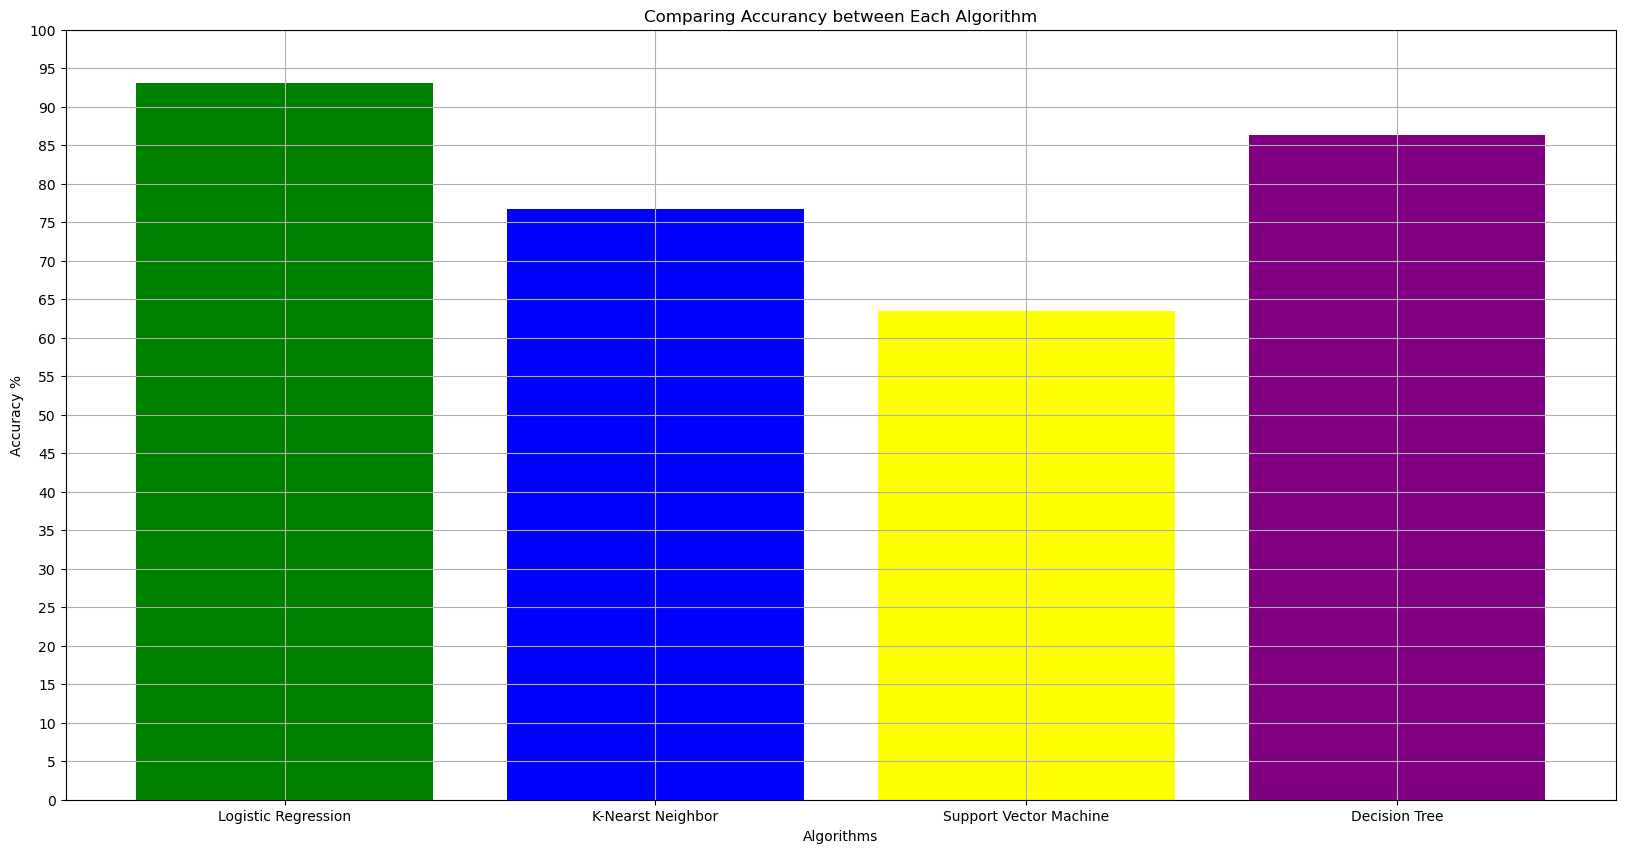

Logistict Regression: 93.10%
K-Nearest Neighbour: 76.73%
Support Vector Machine: 63.51%
Decision Tree: 86.39%


In [127]:
plt.figure(figsize=(20,10))
plt.grid(True)
plt.bar(x=alg_name, height = acc_all,color=['green','blue','yellow','purple'])

plt.xticks()
plt.ylim((0,100))

plt.yticks(np.arange(0,105,5))
plt.title("Comparing Accurancy between Each Algorithm")
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")

plt.show()

print("Logistict Regression: {0:.2f}%".format(acc_all[0]))
print("K-Nearest Neighbour: {0:.2f}%".format(acc_all[1]))
print("Support Vector Machine: {0:.2f}%".format(acc_all[2]))
print("Decision Tree: {0:.2f}%".format(acc_all[3]))


In [128]:
#Compare precisions
#Store each algorithm precisions in side the pre_all
pre_all = []
pre_all.append(log_precision*100)
pre_all.append(knn_precision*100)
pre_all.append(svm_precision*100)
pre_all.append(dct_precision*100)


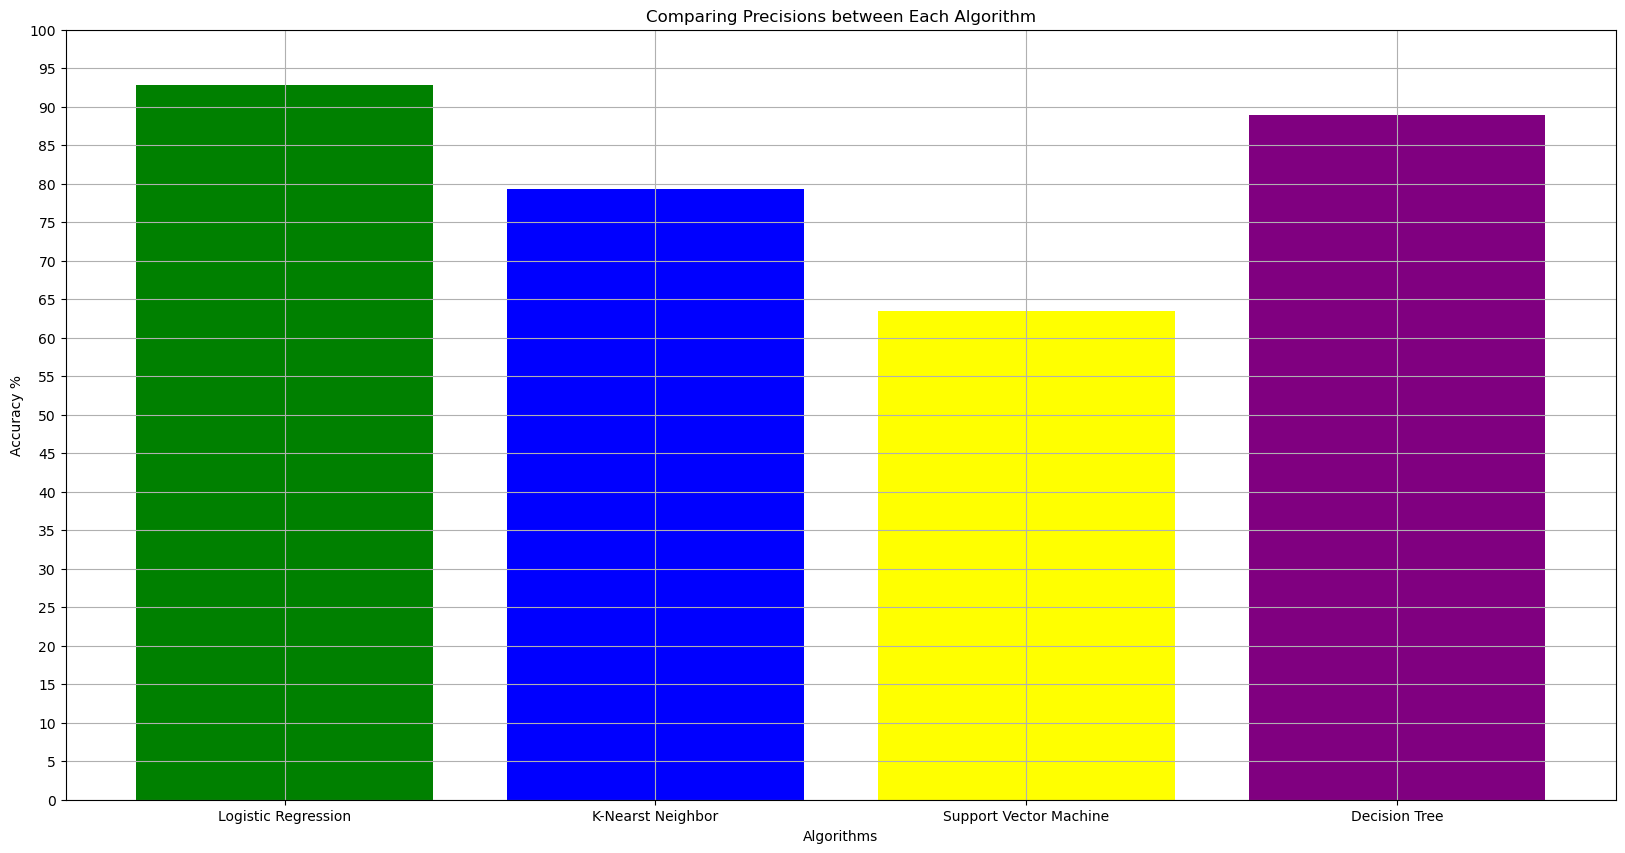

Logistict Regression: 92.84%
K-Nearest Neighbour: 79.31%
Support Vector Machine: 63.51%
Decision Tree: 88.92%


In [129]:
plt.figure(figsize=(20,10))
plt.grid(True)
plt.bar(x=alg_name, height = pre_all,color=['green','blue','yellow','purple'])

plt.xticks()
plt.ylim((0,100))

plt.yticks(np.arange(0,105,5))
plt.title("Comparing Precisions between Each Algorithm")
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")

plt.show()

print("Logistict Regression: {0:.2f}%".format(pre_all[0]))
print("K-Nearest Neighbour: {0:.2f}%".format(pre_all[1]))
print("Support Vector Machine: {0:.2f}%".format(pre_all[2]))
print("Decision Tree: {0:.2f}%".format(pre_all[3]))


In [130]:
#Compare recall
#Store each algorithm precisions in side the rec_all
rec_all = []
rec_all.append(log_recall*100)
rec_all.append(knn_recall*100)
rec_all.append(svm_recall*100)
rec_all.append(dct_recall*100)


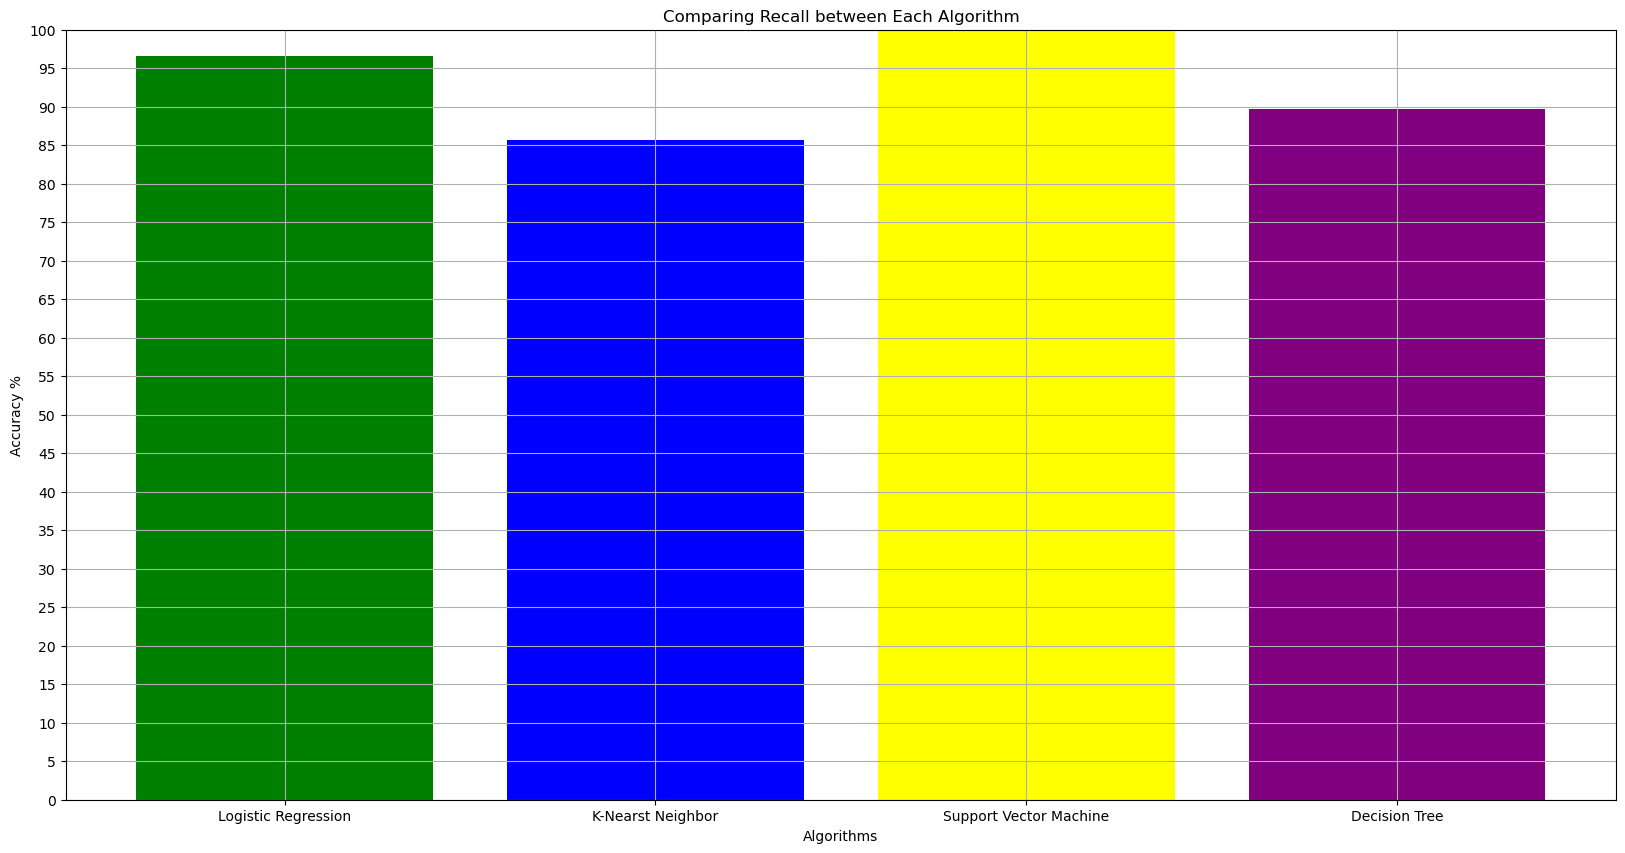

Logistict Regression: 96.58%
K-Nearest Neighbour: 85.71%
Support Vector Machine: 100.00%
Decision Tree: 89.75%


In [131]:
plt.figure(figsize=(20,10))
plt.grid(True)
plt.bar(x=alg_name, height = rec_all,color=['green','blue','yellow','purple'])

plt.xticks()
plt.ylim((0,100))

plt.yticks(np.arange(0,105,5))
plt.title("Comparing Recall between Each Algorithm")
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")

plt.show()

print("Logistict Regression: {0:.2f}%".format(rec_all[0]))
print("K-Nearest Neighbour: {0:.2f}%".format(rec_all[1]))
print("Support Vector Machine: {0:.2f}%".format(rec_all[2]))
print("Decision Tree: {0:.2f}%".format(rec_all[3]))


In [132]:
#Compare f1-score
#Store each algorithm f1-score in side the f1_all
f1_all = []
f1_all.append(log_f1*100)
f1_all.append(knn_f1*100)
f1_all.append(svm_f1*100)
f1_all.append(dct_f1*100)


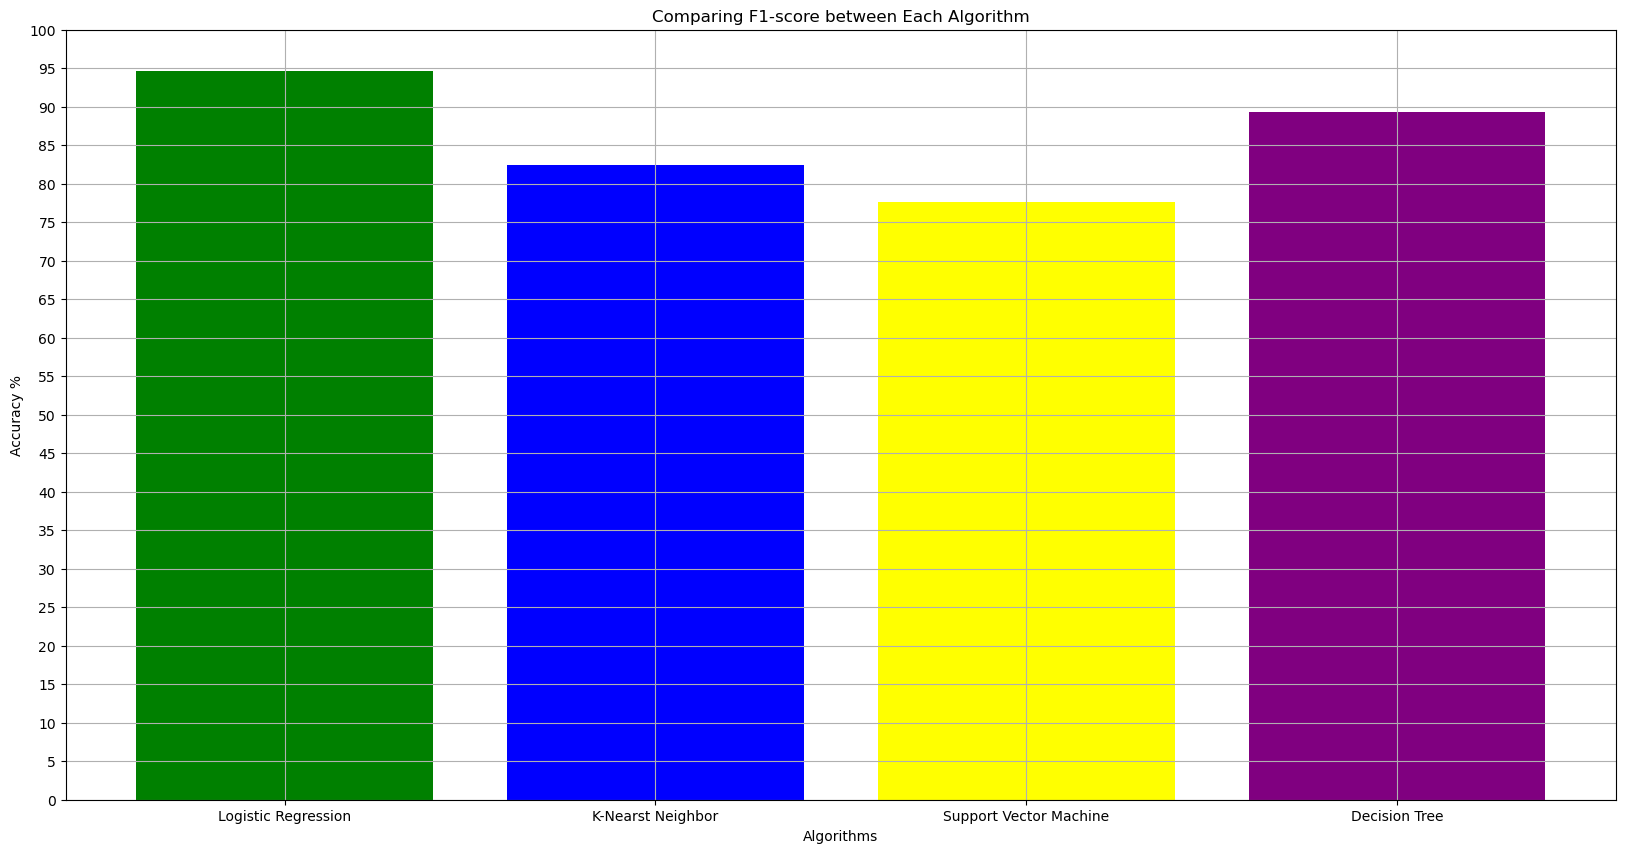

Logistict Regression: 94.67%
K-Nearest Neighbour: 82.39%
Support Vector Machine: 77.68%
Decision Tree: 89.34%


In [133]:
plt.figure(figsize=(20,10))
plt.grid(True)
plt.bar(x=alg_name, height = f1_all,color=['green','blue','yellow','purple'])

plt.xticks()
plt.ylim((0,100))

plt.yticks(np.arange(0,105,5))
plt.title("Comparing F1-score between Each Algorithm")
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")

plt.show()

print("Logistict Regression: {0:.2f}%".format(f1_all[0]))
print("K-Nearest Neighbour: {0:.2f}%".format(f1_all[1]))
print("Support Vector Machine: {0:.2f}%".format(f1_all[2]))
print("Decision Tree: {0:.2f}%".format(f1_all[3]))


# Deployment

In [134]:
import pickle

pkl_nameFile = "pickle_LOG_Model.pkl"

with open(pkl_nameFile, 'wb') as file:
    pickle.dump(logmodel, file)  


In [135]:
with open("pickle_LOG_Model.pkl", 'rb') as file:
    Pickled_LOG_Model  = pickle.load(file)
    

Pickled_LOG_Model

LogisticRegression(max_iter=10000)

In [136]:
def std_predictor(Marital_status, Application_mode, Application_order, Course,
                  Daytime_evening_attendance, Previous_qualification_grade,
                  Admission_grade, Displaced, Debtor, Gender,
                  Scholarship_holder, Age_at_enrollment,
                  Curricular_units_2nd_sem_enrolled,
                  Curricular_units_2nd_sem_evaluations,
                  Curricular_units_2nd_sem_approved,
                  Curricular_units_2nd_sem_grade, Unemployment_rate,
                  Inflation_rate, GDP, Parents_s_Qualification):
    
    
    
    
    
    
                   
    predictor = logmodel.predict([[Marital_status, Application_mode, Application_order, Course,
                                  Daytime_evening_attendance, Previous_qualification_grade,
                                  Admission_grade, Displaced, Debtor, Gender, Scholarship_holder, 
                                  Age_at_enrollment, Curricular_units_2nd_sem_enrolled, 
                                  Curricular_units_2nd_sem_evaluations, Curricular_units_2nd_sem_approved, 
                                  Curricular_units_2nd_sem_grade, Unemployment_rate, Inflation_rate, 
                                  GDP, Parents_s_Qualification]])
    if(predictor ==[1]):
        pred='graduate'
    else:
        pred ='dropout'
    return pred


In [137]:
# Function to get integer input within a specified range
def getInt(prompt, min_value, max_value):
    while True:
        try:
            user_input = int(input(prompt))
            if min_value <= user_input <= max_value:
                return user_input
            else:
                print(f"Please enter an integer between {min_value} and {max_value}.")
        except ValueError:
            print("Invalid input. Please enter an integer.")

# Function to get input from a list of allowed values
def getList(prompt, allowed_values):
    while True:
        user_input = input(prompt)
        if user_input in map(str, allowed_values):
            return user_input
        else:
            print("Invalid input. Please enter a valid value from the list:", allowed_values)
            
# Function to get a float input within a specified range
def getFloat(prompt, min_value, max_value):
    while True:
        try:
            user_input = float(input(prompt))
            if min_value <= user_input <= max_value:
                return user_input
            else:
                print(f"Please enter a number between {min_value} and {max_value}.")
        except ValueError:
            print("Invalid input. Please enter a number.")


In [138]:
#Special Value list 
# Application mode
am_number = [1, 2, 7, 10, 15, 16, 17, 18, 26, 27, 39, 42, 43, 44, 51, 53, 57]

#Course
cos_number = [33,171,8014,9003,9070,9085,9119,9130,9147,9238,9254,9500,9556,9670,9773,9853]

#Parents's Qualification
pq_num=[1,2,3,4,5,6,9,10,11,12,14,18,19,22,26,27,29,30,34,35,36,37,38,39,40,41,42,43,44]

In [139]:
def main():
    
    Marital_status = int(getInt("Enter Marital status (1-6): ", 1, 6))
    Application_mode = int(getList("Enter Application mode:",am_number))
    Application_order = int(getInt("Enter Application order (0-9):",0,9))
    Course = int(getList("Enter Course:",[str(i) for i in cos_number]))
    Daytime_evening_attendance =int(getInt("Enter Daytime evening attendance(0-1):",0,1))
    Previous_qualification_grade = float(getFloat("Enter Previous qualification grade(0-200):",0,200))
    Admission_grade = float(getFloat("Enter Admission grade(0-200):",0,200))
    Displaced = int(getInt("Enter Displaced(0-1):",0,1))
    Debtor = int(getInt ("Enter Debtor(0-1):",0,1))
    Gender = int(getInt("Enter Gender(0-1):",0,1))
    Scholarship_holder = int(getInt("Enter Scholarship holder(0-1):",0,1))
    Age_at_enrollment = int(getInt("Enter Age at Enrollment:",15,110))
    Curricular_units_2nd_sem_enrolled = int(getInt("Enter Curricular unit 2nd sem enrolled(0-35):",0,35))
    Curricular_units_2nd_sem_evaluations = int(getInt("Enter Curricular unit 2nd sem evaluations(0-35):",0,35)) 
    Curricular_units_2nd_sem_approved = int(getInt("Enter Curricular unit 2nd sem approved(0-35):",0,35))
    Curricular_units_2nd_sem_grade = float(getFloat("Enter Curricular unit 2nd sem grade(0-200):",0,200))
    Unemployment_rate = float(getFloat("Enter Unemployment rate:",0.00,100.00))
    Inflation_rate= float(getFloat("Enter Infaltion Rate:",-100.00,100.00))
    GDP = float(getFloat("Enter GDP:",0.00,100.00))
    Parents_s_Qualification = int(getList("Enter Parents's Qualification:",pq_num))

    predictResult = std_predictor(Marital_status, Application_mode, Application_order, Course,
                  Daytime_evening_attendance, Previous_qualification_grade,
                  Admission_grade, Displaced, Debtor, Gender,
                  Scholarship_holder, Age_at_enrollment,
                  Curricular_units_2nd_sem_enrolled,
                  Curricular_units_2nd_sem_evaluations,
                  Curricular_units_2nd_sem_approved,
                  Curricular_units_2nd_sem_grade, Unemployment_rate,
                  Inflation_rate, GDP, Parents_s_Qualification)
    
    print("=================================================")
    print("Final Predicted Machine Result: ", predictResult)
    return
    
    

In [140]:
#call main function to ask user insert data and do the prediction
main()

Enter Marital status (1-6): 1
Enter Application mode:15
Enter Application order (0-9):1
Enter Course:9254
Enter Daytime evening attendance(0-1):1
Enter Previous qualification grade(0-200):160
Enter Admission grade(0-200):142.5
Enter Displaced(0-1):1
Enter Debtor(0-1):0
Enter Gender(0-1):0
Enter Scholarship holder(0-1):0
Enter Age at Enrollment:19
Enter Curricular unit 2nd sem enrolled(0-35):6
Enter Curricular unit 2nd sem evaluations(0-35):6
Enter Curricular unit 2nd sem approved(0-35):6
Enter Curricular unit 2nd sem grade(0-200):13.67
Enter Unemployment rate:13.9
Enter Infaltion Rate:-0.3
Enter GDP:0.79
Enter Parents's Qualification:1
Final Predicted Machine Result:  graduate
